# Geodemographic Clustering Case Study

Demonstrates that learned embeddings (100D) can be used for geodemographic classification.
Creates 8-cluster classifications from AE and PCA embeddings, evaluates cluster quality.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import os

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score, 
    silhouette_samples,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
    v_measure_score
)

import warnings
warnings.filterwarnings('ignore')

## Configuration

In [2]:
# Parameters
target_dim = 64
n_clusters = 8  # Match OAC supergroups
random_seed = 20210321

# Paths
data_path = "../AE_outputs/engcensus_all/"
working_dir = data_path + "250epoch_scan_lin"
cleaned_data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
geo_path = "../data/geofiles/Output_Areas_(December_2021)_Boundaries_EW_BFE_(V9)_and_RUC.geojson"
oac_path = "../data/OAC/OAC_assignment.csv"

# Output
output_dir = "./plots/geodemo_clustering/"
os.makedirs(output_dir, exist_ok=True)

print(f"Creating {n_clusters} clusters from {target_dim}D embeddings")
print(f"Random seed: {random_seed}")

Creating 8 clusters from 64D embeddings
Random seed: 20210321


## Load Data

In [3]:
# Load original census data
print("Loading census data...")
df_census = pd.read_parquet(cleaned_data_path)
df_census = df_census.set_index('OA')
print(f"Census data: {df_census.shape}")

# Load PCA embeddings (compute on the fly)
print(f"\nComputing PCA {target_dim}D embeddings...")
pca = PCA(n_components=target_dim, random_state=random_seed)
pca_embeddings = pca.fit_transform(df_census)
pca_latent_df = pd.DataFrame(pca_embeddings, index=df_census.index)
print(f"PCA embeddings: {pca_latent_df.shape}")
print(f"Explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Load AE embeddings
ae_latent_path = f"{working_dir}/census_geodemo__bottleneck_{target_dim}_v1__latent.csv"
print(f"\nLoading AE embeddings from: {ae_latent_path}")
if os.path.exists(ae_latent_path):
    ae_latent_df = pd.read_csv(ae_latent_path, index_col="OA")
    ae_latent_df = ae_latent_df.reindex(df_census.index)
    print(f"AE embeddings: {ae_latent_df.shape}")
else:
    raise FileNotFoundError(f"AE latent file not found at {ae_latent_path}")

# Load OAC
print(f"\nLoading OAC classifications...")
oac = pd.read_csv(oac_path)
oac = oac[['Geography_Code', 'Supergroup8']].rename(columns={'Geography_Code': 'OA'})
oac = oac.set_index('OA')
oac = oac.reindex(df_census.index)
print(f"OAC: {oac.shape}")
print(f"OAC Supergroups: {oac['Supergroup8'].nunique()} unique groups")

Loading census data...
Census data: (188880, 408)

Computing PCA 64D embeddings...
PCA embeddings: (188880, 64)
Explained variance: 0.968

Loading AE embeddings from: ../AE_outputs/engcensus_all/250epoch_scan_lin/census_geodemo__bottleneck_64_v1__latent.csv
AE embeddings: (188880, 64)

Loading OAC classifications...
OAC: (188880, 1)
OAC Supergroups: 8 unique groups



Generating PCA clustergram...
K=1 skipped. Mean computed from data directly.
K=2 fitted in 2.330 seconds.
K=3 fitted in 2.462 seconds.
K=4 fitted in 3.338 seconds.
K=5 fitted in 3.391 seconds.
K=6 fitted in 3.178 seconds.
K=7 fitted in 5.107 seconds.
K=8 fitted in 5.044 seconds.
K=9 fitted in 5.751 seconds.
Generating AE clustergram...
K=1 skipped. Mean computed from data directly.
K=2 fitted in 2.170 seconds.
K=3 fitted in 2.376 seconds.
K=4 fitted in 3.901 seconds.
K=5 fitted in 3.950 seconds.
K=6 fitted in 3.539 seconds.
K=7 fitted in 4.266 seconds.
K=8 fitted in 4.638 seconds.
K=9 fitted in 6.011 seconds.


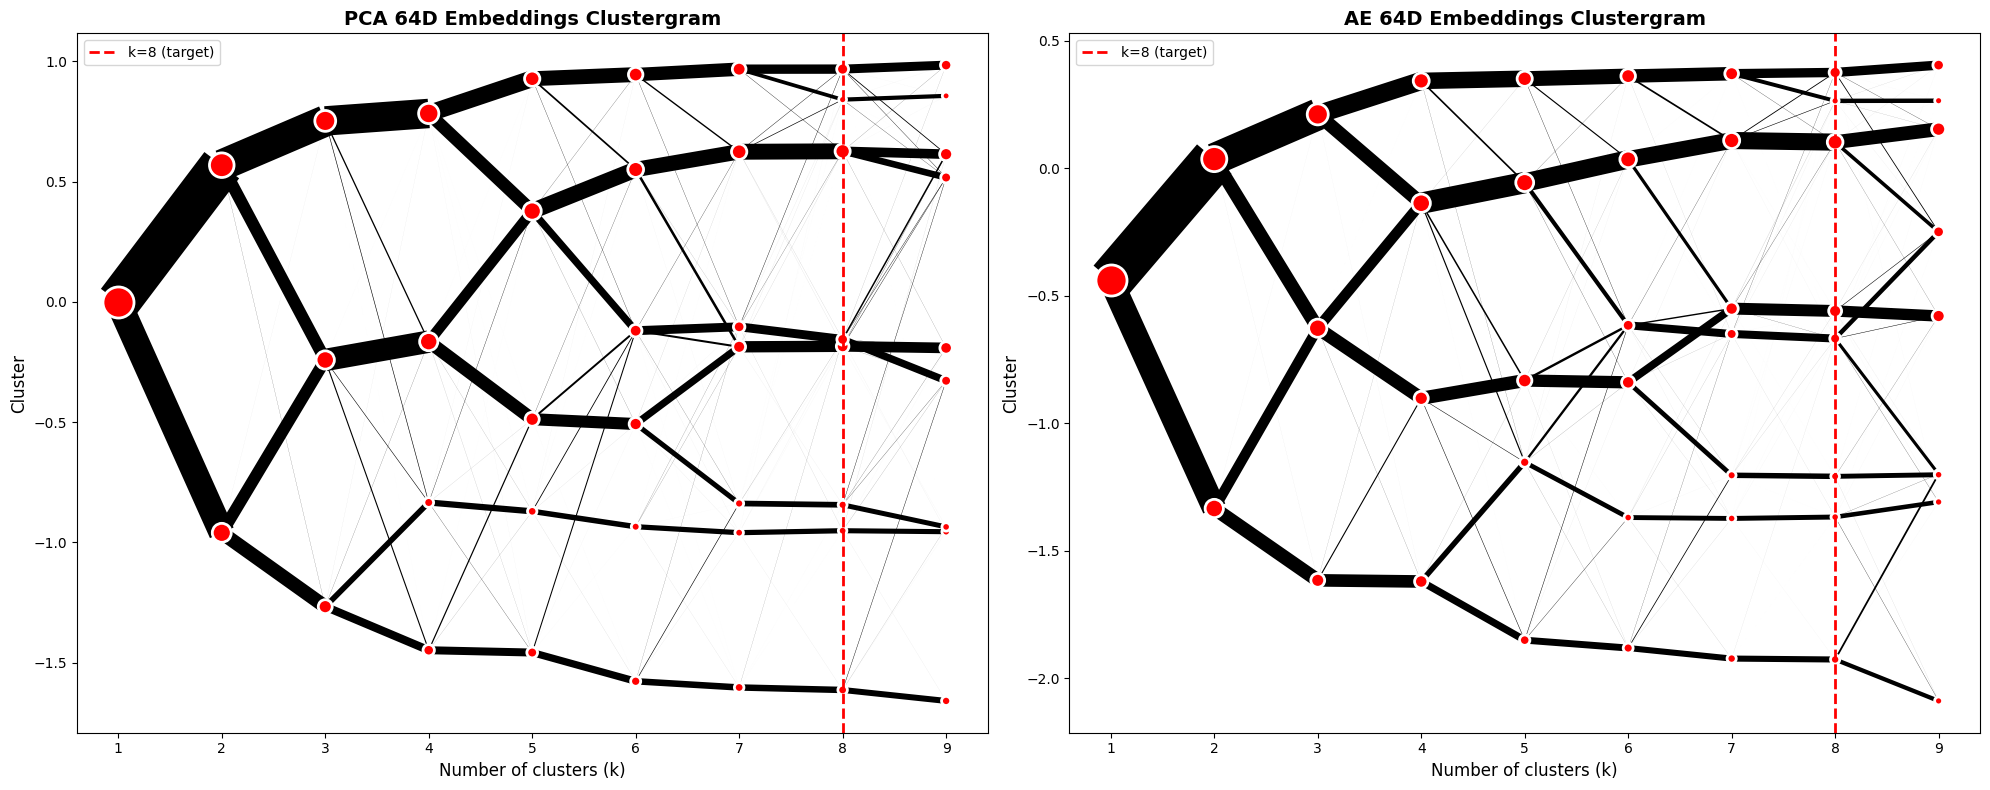


✓ Clustergrams saved to ./plots/geodemo_clustering//clustergram_comparison_64d.png


In [4]:
# Make a clustergram for PCA and AE embeddings
import clustergram



# Create clustergram for PCA embeddings
print("\nGenerating PCA clustergram...")
cgram_pca = clustergram.Clustergram(range(1,10), n_init=10, random_state=random_seed)
cgram_pca.fit(pca_latent_df)

# Create clustergram for AE embeddings  
print("Generating AE clustergram...")
cgram_ae = clustergram.Clustergram(range(1,10), n_init=10, random_state=random_seed)
cgram_ae.fit(ae_latent_df)

# Plot both clustergrams side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# PCA clustergram
cgram_pca.plot(ax=axes[0], figsize=None)
axes[0].set_title(f'PCA {target_dim}D Embeddings Clustergram', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of clusters (k)', fontsize=12)
axes[0].set_ylabel('Cluster', fontsize=12)
axes[0].axvline(x=n_clusters, color='red', linestyle='--', linewidth=2, label=f'k={n_clusters} (target)')
axes[0].legend()

# AE clustergram
cgram_ae.plot(ax=axes[1], figsize=None)
axes[1].set_title(f'AE {target_dim}D Embeddings Clustergram', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of clusters (k)', fontsize=12)
axes[1].set_ylabel('Cluster', fontsize=12)
axes[1].axvline(x=n_clusters, color='red', linestyle='--', linewidth=2, label=f'k={n_clusters} (target)')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{output_dir}/clustergram_comparison_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Clustergrams saved to {output_dir}/clustergram_comparison_{target_dim}d.png")

## K-Means Clustering

In [5]:
print(f"Performing K-Means clustering (k={n_clusters})...\n")

# PCA clustering
print("PCA embeddings...")
kmeans_pca = KMeans(n_clusters=n_clusters, random_state=random_seed, n_init=100, max_iter=1000)
pca_clusters = kmeans_pca.fit_predict(pca_latent_df)
print(f"  Inertia: {kmeans_pca.inertia_:.2f}")
print(f"  Iterations: {kmeans_pca.n_iter_}")

# AE clustering
print("\nAE embeddings...")
kmeans_ae = KMeans(n_clusters=n_clusters, random_state=random_seed, n_init=100, max_iter=1000)
ae_clusters = kmeans_ae.fit_predict(ae_latent_df)
print(f"  Inertia: {kmeans_ae.inertia_:.2f}")
print(f"  Iterations: {kmeans_ae.n_iter_}")

# Create results dataframe
clusters_df = pd.DataFrame({
    'pca_cluster': pca_clusters,
    'ae_cluster': ae_clusters,
    'oac_supergroup': oac['Supergroup8'].values
}, index=df_census.index)

print("\nCluster distributions:")
print("\nPCA clusters:")
print(clusters_df['pca_cluster'].value_counts().sort_index())
print("\nAE clusters:")
print(clusters_df['ae_cluster'].value_counts().sort_index())

Performing K-Means clustering (k=8)...

PCA embeddings...
  Inertia: 211990.88
  Iterations: 27

AE embeddings...
  Inertia: 141165.42
  Iterations: 48

Cluster distributions:

PCA clusters:
pca_cluster
0    14326
1    27588
2    26127
3    17693
4    12089
5    44673
6    15622
7    30762
Name: count, dtype: int64

AE clusters:
ae_cluster
0    12496
1    32657
2    13532
3    14804
4    22431
5    16488
6    28317
7    48155
Name: count, dtype: int64


In [6]:
# Step 1: Load geometries
print("Loading geometries for mapping...")
gdf = gpd.read_file("Output_Areas_2021_EW_BGC_V2_-5587136561181621407.gpkg")
gdf = gdf[['OA21CD', 'geometry']].rename(columns={'OA21CD': 'OA'})
gdf = gdf.set_index('OA')

# Merge with clusters
gdf = gdf.join(clusters_df)
print(f"GeoDataFrame: {gdf.shape}")

# Load London boundary for plotting
print("Loading London boundary...")
lads_gdf = gpd.read_file("Local_Authority_Districts_December_2022_UK_BGC_V2_5759908710055972638.gpkg")
london_boundary = lads_gdf[lads_gdf['LAD22CD'].str.startswith('E09')].dissolve()
if london_boundary.crs != gdf.crs:
    london_boundary = london_boundary.to_crs(gdf.crs)

# Load England/Wales boundary for plotting
print("Loading country boundaries...")
countries_gdf = gpd.read_file("Countries_December_2022_UK_BGC_1943732719298389253.gpkg")
eng_wales_gdf = countries_gdf[countries_gdf['CTRY22CD'].str.startswith(('E', 'W'))]
if eng_wales_gdf.crs != gdf.crs:
    eng_wales_gdf = eng_wales_gdf.to_crs(gdf.crs)

print("✓ All geometries loaded")

Loading geometries for mapping...
GeoDataFrame: (188880, 4)
Loading London boundary...
Loading country boundaries...
✓ All geometries loaded



Creating publication-quality map...


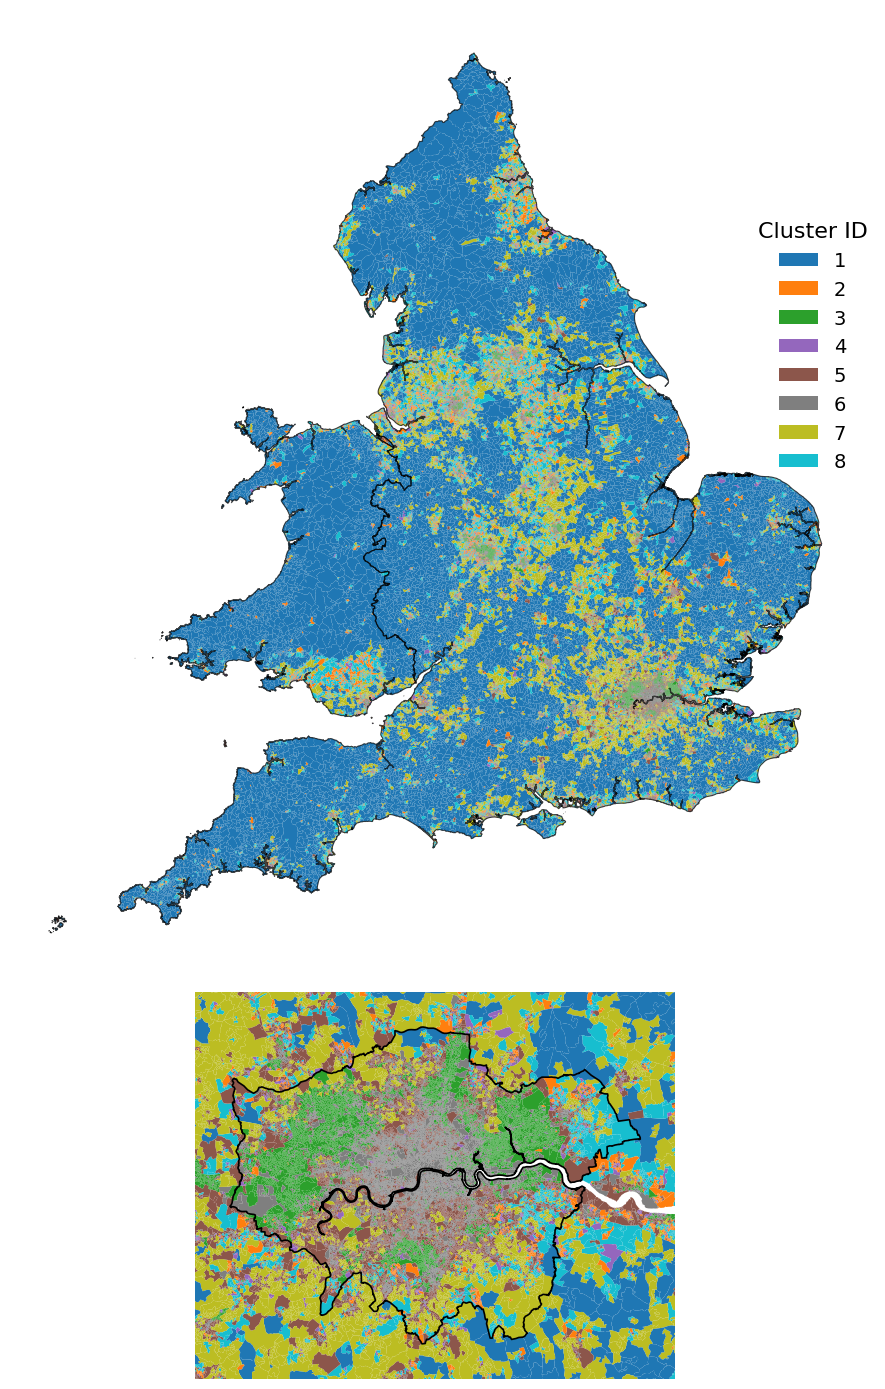

✓ Saved publication-quality map to ./plots/geodemo_clustering//publication_map_ae_64d.png


In [30]:
# Step 2: Create the map
print("\nCreating publication-quality map...")

# London bounds with buffer (IN METERS - EPSG:27700)
minx, miny, maxx, maxy = london_boundary.total_bounds
buffer = 5000  # 5km buffer
london_bounds = {
    'minx': minx - buffer, 
    'maxx': maxx + buffer, 
    'miny': miny - buffer, 
    'maxy': maxy + buffer
}

# Filter London data
gdf_london = gdf.cx[london_bounds['minx']:london_bounds['maxx'], 
                    london_bounds['miny']:london_bounds['maxy']]

# Stacked figure with height ratios
fig, axes = plt.subplots(2, 1, figsize=(10, 14), 
                         gridspec_kw={'height_ratios': [2.5, 1]})
ax_uk = axes[0]
ax_ldn = axes[1]

# Color map
cmap = plt.cm.get_cmap('tab10', n_clusters)

# === UK Map ===
gdf.plot(column='ae_cluster', ax=ax_uk, cmap=cmap,
         linewidth=0, edgecolor='none', legend=False)
eng_wales_gdf.boundary.plot(ax=ax_uk, linewidth=0.8, edgecolor='black', alpha=0.7)
ax_uk.axis('off')

# === London Map ===
gdf_london.plot(column='ae_cluster', ax=ax_ldn, cmap=cmap,
                linewidth=0, edgecolor='none', legend=False)
london_boundary.boundary.plot(ax=ax_ldn, linewidth=1.2, edgecolor='black')
ax_ldn.set_xlim(london_bounds['minx'], london_bounds['maxx'])
ax_ldn.set_ylim(london_bounds['miny'], london_bounds['maxy'])
ax_ldn.set_aspect('equal')
ax_ldn.axis('off')

# Add borders
for ax in [ax_uk, ax_ldn]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

# Legend - higher, no frame
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cmap(i-1), label=str(i)) 
                   for i in range(1, n_clusters + 1)]
fig.legend(handles=legend_elements, loc='upper right', ncol=1,
           fontsize=14, frameon=False, title='Cluster ID', title_fontsize=16,
           bbox_to_anchor=(0.95, 0.85))

plt.tight_layout()
plt.savefig(f"{output_dir}/publication_map_ae_{target_dim}d.png", 
            dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print(f"✓ Saved publication-quality map to {output_dir}/publication_map_ae_{target_dim}d.png")

## Cluster Quality Metrics

Evaluating cluster quality using multiple metrics:
- **Silhouette Score**: Measures how similar an object is to its own cluster compared to other clusters (-1 to 1, higher is better)
- **Davies-Bouldin Index**: Average similarity between clusters (lower is better)
- **Calinski-Harabasz Score**: Ratio of between-cluster to within-cluster variance (higher is better)

In [ ]:
print("Computing cluster quality metrics...\n")

# WSSC (Within-cluster Sum of Squares) - already computed by KMeans
print("Within-cluster Sum of Squares (WSSC / Inertia - lower is better):")
wssc_pca = kmeans_pca.inertia_
wssc_ae = kmeans_ae.inertia_
print(f"  PCA:  {wssc_pca:.2f}")
print(f"  AE:   {wssc_ae:.2f}")
print(f"  Difference: {wssc_ae - wssc_pca:+.2f}")

# For silhouette scores, use a sample to speed up computation
# (Silhouette is O(n²) in memory and computation)
sample_size = 10000  # Use 10k samples instead of 188k for speed
print(f"\nUsing {sample_size:,} sample for silhouette computation (full dataset: {len(pca_latent_df):,})")

# Create stratified sample (proportional from each cluster)
np.random.seed(random_seed)
pca_sample_idx = []
ae_sample_idx = []

for i in range(n_clusters):
    # PCA samples
    pca_cluster_idx = np.where(pca_clusters == i)[0]
    pca_n_sample = max(int(len(pca_cluster_idx) * sample_size / len(pca_clusters)), 10)
    pca_sample_idx.extend(np.random.choice(pca_cluster_idx, size=min(pca_n_sample, len(pca_cluster_idx)), replace=False))
    
    # AE samples
    ae_cluster_idx = np.where(ae_clusters == i)[0]
    ae_n_sample = max(int(len(ae_cluster_idx) * sample_size / len(ae_clusters)), 10)
    ae_sample_idx.extend(np.random.choice(ae_cluster_idx, size=min(ae_n_sample, len(ae_cluster_idx)), replace=False))

pca_sample_idx = np.array(pca_sample_idx)
ae_sample_idx = np.array(ae_sample_idx)

# Silhouette scores (on sample)
print("\nSilhouette Scores (sampled):")
silhouette_pca = silhouette_score(pca_latent_df.iloc[pca_sample_idx], pca_clusters[pca_sample_idx])
silhouette_ae = silhouette_score(ae_latent_df.iloc[ae_sample_idx], ae_clusters[ae_sample_idx])
print(f"  PCA:  {silhouette_pca:.4f}")
print(f"  AE:   {silhouette_ae:.4f}")
print(f"  Difference: {silhouette_ae - silhouette_pca:+.4f}")

# Davies-Bouldin Index (lower is better) - FAST, use full data
print("\nDavies-Bouldin Index (lower is better):")
db_pca = davies_bouldin_score(pca_latent_df, pca_clusters)
db_ae = davies_bouldin_score(ae_latent_df, ae_clusters)
print(f"  PCA:  {db_pca:.4f}")
print(f"  AE:   {db_ae:.4f}")
print(f"  Difference: {db_ae - db_pca:+.4f}")

# Calinski-Harabasz Score (higher is better) - FAST, use full data
print("\nCalinski-Harabasz Score (higher is better):")
ch_pca = calinski_harabasz_score(pca_latent_df, pca_clusters)
ch_ae = calinski_harabasz_score(ae_latent_df, ae_clusters)
print(f"  PCA:  {ch_pca:.2f}")
print(f"  AE:   {ch_ae:.2f}")
print(f"  Difference: {ch_ae - ch_pca:+.2f}")

# Per-cluster silhouette scores (on sample)
print("\nPer-cluster silhouette scores (sampled):")
silhouette_pca_samples = silhouette_samples(pca_latent_df.iloc[pca_sample_idx], pca_clusters[pca_sample_idx])
silhouette_ae_samples = silhouette_samples(ae_latent_df.iloc[ae_sample_idx], ae_clusters[ae_sample_idx])

print("\nPCA:")
for i in range(n_clusters):
    cluster_silhouette = silhouette_pca_samples[pca_clusters[pca_sample_idx] == i].mean()
    cluster_size = (pca_clusters == i).sum()
    print(f"  Cluster {i}: {cluster_silhouette:.4f} (n={cluster_size:,})")

print("\nAE:")
for i in range(n_clusters):
    cluster_silhouette = silhouette_ae_samples[ae_clusters[ae_sample_idx] == i].mean()
    cluster_size = (ae_clusters == i).sum()
    print(f"  Cluster {i}: {cluster_silhouette:.4f} (n={cluster_size:,})")

# Store for comparison
quality_metrics = pd.DataFrame({
    'Metric': ['WSSC/Inertia', 'Silhouette Score', 'Davies-Bouldin', 'Calinski-Harabasz'],
    'PCA': [wssc_pca, silhouette_pca, db_pca, ch_pca],
    'AE': [wssc_ae, silhouette_ae, db_ae, ch_ae],
    'Better': ['Lower', 'Higher', 'Lower', 'Higher']
})
quality_metrics['Winner'] = quality_metrics.apply(
    lambda row: 'AE' if (row['Better'] == 'Higher' and row['AE'] > row['PCA']) or 
                        (row['Better'] == 'Lower' and row['AE'] < row['PCA']) else 'PCA',
    axis=1
)

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(quality_metrics.to_string(index=False))

# Save results
data_dir = f"{output_dir}/data/"
os.makedirs(data_dir, exist_ok=True)
quality_metrics.to_csv(f"{data_dir}/quality_metrics_{target_dim}d.csv", index=False)

# Save sample indices and silhouette samples for plotting
np.savez(f"{data_dir}/silhouette_data_{target_dim}d.npz",
         pca_sample_idx=pca_sample_idx,
         ae_sample_idx=ae_sample_idx,
         silhouette_pca_samples=silhouette_pca_samples,
         silhouette_ae_samples=silhouette_ae_samples,
         pca_clusters_sampled=pca_clusters[pca_sample_idx],
         ae_clusters_sampled=ae_clusters[ae_sample_idx])

print(f"\n✓ Saved quality metrics and silhouette data to {data_dir}")

Computing cluster quality metrics...

Within-cluster Sum of Squares (WSSC / Inertia - lower is better):
  PCA:  211990.88
  AE:   141165.42
  Difference: -70825.46

Using 10,000 sample for silhouette computation (full dataset: 188,880)

Silhouette Scores (sampled):
  PCA:  0.1290
  AE:   0.1187
  Difference: -0.0103

Davies-Bouldin Index (lower is better):
  PCA:  1.8580
  AE:   1.9540
  Difference: +0.0960

Calinski-Harabasz Score (higher is better):
  PCA:  27031.28
  AE:   28195.24
  Difference: +1163.96

Per-cluster silhouette scores (sampled):

PCA:
  Cluster 0: 0.1294 (n=14,326)
  Cluster 1: 0.1574 (n=27,588)
  Cluster 2: 0.0599 (n=26,127)
  Cluster 3: 0.1149 (n=17,693)
  Cluster 4: 0.2477 (n=12,089)
  Cluster 5: 0.1464 (n=44,673)
  Cluster 6: 0.0851 (n=15,622)
  Cluster 7: 0.1203 (n=30,762)

AE:
  Cluster 0: 0.2139 (n=12,496)
  Cluster 1: 0.1193 (n=32,657)
  Cluster 2: 0.1177 (n=13,532)
  Cluster 3: 0.0739 (n=14,804)
  Cluster 4: 0.0585 (n=22,431)
  Cluster 5: 0.1033 (n=16,488)


## Comparison to OAC

How well do the learned embeddings align with the official OAC classification?

In [ ]:
print("Comparing to OAC Supergroups...\n")

# Adjusted Rand Index (measures clustering agreement)
print("Adjusted Rand Index (ARI):")
ari_pca = adjusted_rand_score(oac['Supergroup8'].values, pca_clusters)
ari_ae = adjusted_rand_score(oac['Supergroup8'].values, ae_clusters)
print(f"  PCA vs OAC:  {ari_pca:.4f}")
print(f"  AE vs OAC:   {ari_ae:.4f}")
print(f"  Difference:  {ari_ae - ari_pca:+.4f}")

# V-measure (measures clustering quality against ground truth)
print("\nV-Measure Score:")
v_pca = v_measure_score(oac['Supergroup8'].values, pca_clusters)
v_ae = v_measure_score(oac['Supergroup8'].values, ae_clusters)
print(f"  PCA vs OAC:  {v_pca:.4f}")
print(f"  AE vs OAC:   {v_ae:.4f}")
print(f"  Difference:  {v_ae - v_pca:+.4f}")

print("\nInterpretation:")
print("- ARI close to 0: Random labeling")
print("- ARI close to 1: Perfect agreement")
print("- Low ARI expected: Different methods capture different aspects")

Comparing to OAC Supergroups...

Adjusted Rand Index (ARI):
  PCA vs OAC:  0.2819
  AE vs OAC:   0.2773
  Difference:  -0.0045

V-Measure Score:
  PCA vs OAC:  0.4377
  AE vs OAC:   0.4349
  Difference:  -0.0028

Interpretation:
- ARI close to 0: Random labeling
- ARI close to 1: Perfect agreement
- Low ARI expected: Different methods capture different aspects


Creating publication-quality AE cluster vs OAC overlap visualisation...



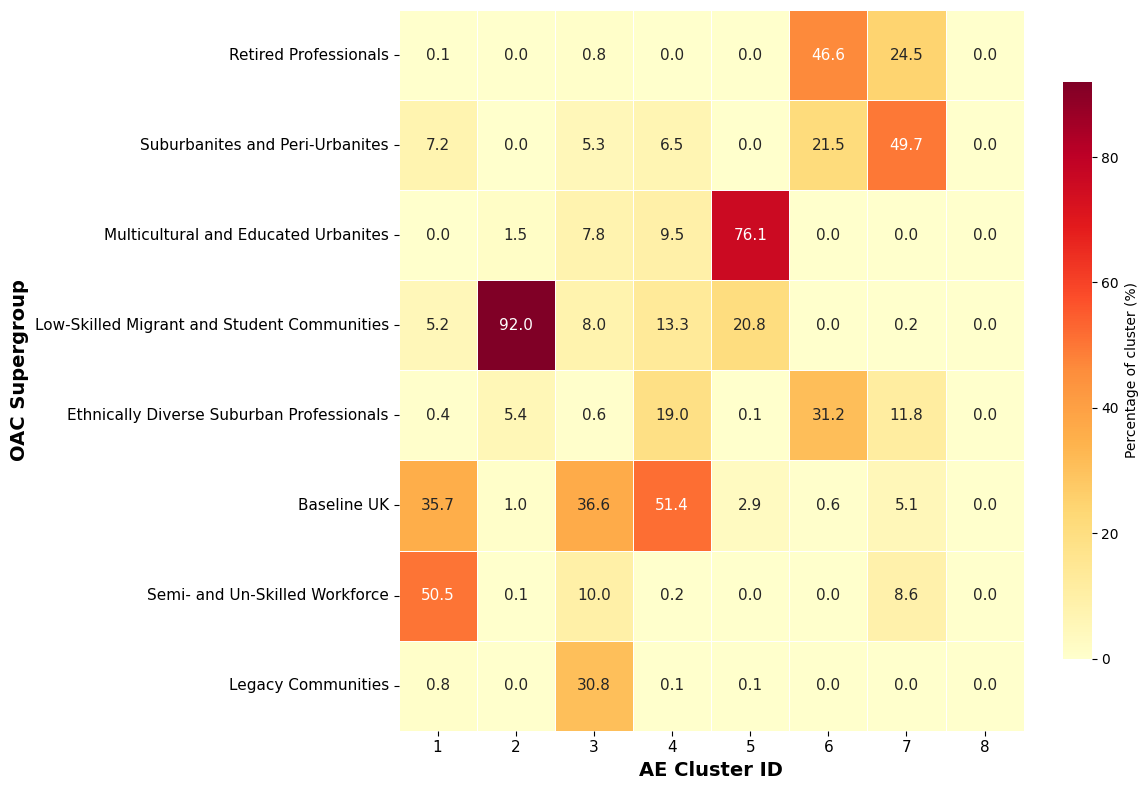

✓ Saved heatmap to ./plots/geodemo_clustering//ae_oac_overlap_publication_64d.png

AE Cluster vs OAC Supergroup Overlap Table
                             OAC Supergroup      Cluster 1      Cluster 2     Cluster 3      Cluster 4      Cluster 5      Cluster 6      Cluster 7 Cluster 8
                      Retired Professionals      40 (0.1%)       0 (0.0%)    118 (0.8%)       5 (0.0%)       0 (0.0%) 13,204 (46.6%) 11,819 (24.5%)  0 (0.0%)
            Suburbanites and Peri-Urbanites   2,364 (7.2%)       0 (0.0%)    779 (5.3%)   1,454 (6.5%)       1 (0.0%)  6,091 (21.5%) 23,940 (49.7%)  0 (0.0%)
       Multicultural and Educated Urbanites       2 (0.0%)     207 (1.5%)  1,159 (7.8%)   2,135 (9.5%) 12,549 (76.1%)       0 (0.0%)       1 (0.0%)  0 (0.0%)
Low-Skilled Migrant and Student Communities   1,698 (5.2%) 12,443 (92.0%)  1,184 (8.0%)  2,987 (13.3%)  3,430 (20.8%)       1 (0.0%)      78 (0.2%)  0 (0.0%)
  Ethnically Diverse Suburban Professionals     139 (0.4%)     734 (5.4%)     95 (0.

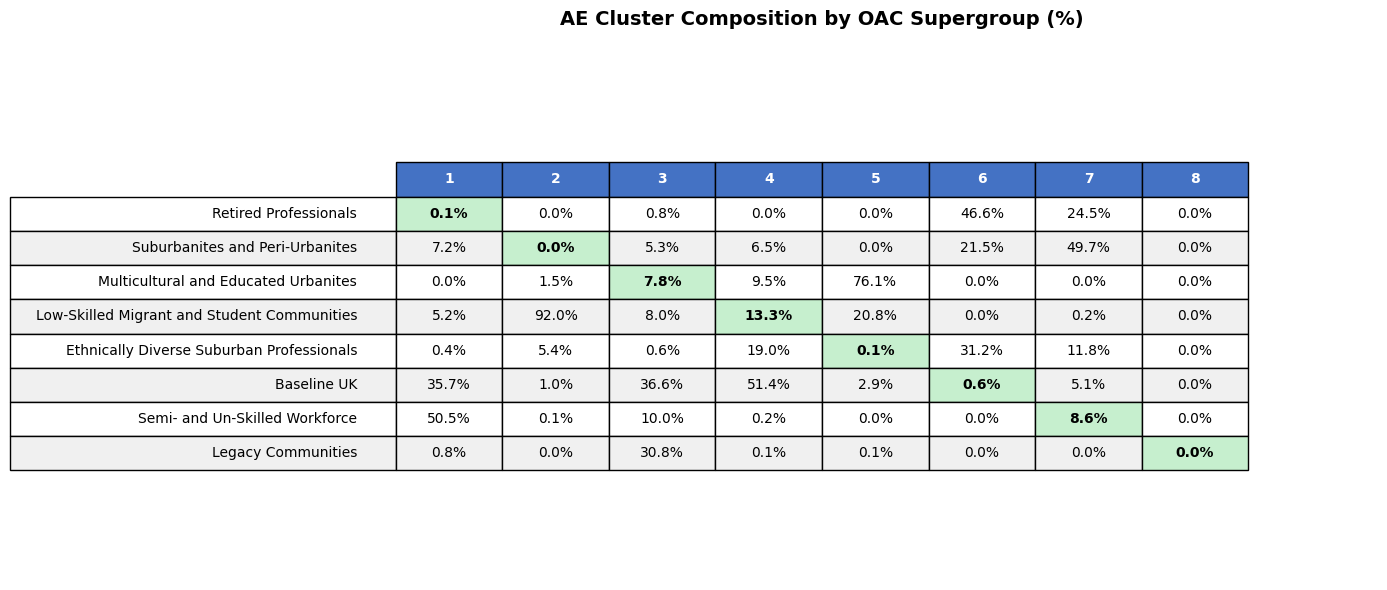

✓ Saved table figure to ./plots/geodemo_clustering//ae_oac_overlap_table_64d.png


In [ ]:
# Publication-quality AE cluster vs OAC overlap analysis
print("Creating publication-quality AE cluster vs OAC overlap visualisation...\n")

# OAC Supergroup names
oac_names = {
    1: "Retired Professionals",
    2: "Suburbanites and Peri-Urbanites",
    3: "Multicultural and Educated Urbanites",
    4: "Low-Skilled Migrant and Student Communities",
    5: "Ethnically Diverse Suburban Professionals",
    6: "Baseline UK",
    7: "Semi- and Un-Skilled Workforce",
    8: "Legacy Communities"
}

# Recompute overlap for AE only with nice labels
def cluster_oac_overlap_named(cluster_labels, oac_labels, oac_names):
    """Return count and percentage matrices with named OAC labels."""
    valid_mask = ~pd.isna(oac_labels)
    oac_valid = oac_labels[valid_mask]
    clusters_valid = cluster_labels[valid_mask]
    
    oac_ids = list(range(1, n_clusters + 1))
    cluster_ids = list(range(1, n_clusters + 1))
    
    counts = pd.crosstab(oac_valid, clusters_valid)
    counts = counts.reindex(index=oac_ids, columns=cluster_ids, fill_value=0)
    
    # Rename index to OAC names
    counts.index = [oac_names[i] for i in counts.index]
    counts.columns = [str(i) for i in counts.columns]
    
    percentages = counts.divide(counts.sum(axis=0).replace(0, np.nan), axis=1) * 100
    percentages = percentages.fillna(0)
    
    return counts, percentages

ae_counts_named, ae_percent_named = cluster_oac_overlap_named(
    ae_clusters, oac['Supergroup8'].values, oac_names
)

# Transpose for flipped axes (clusters on y, OAC on x)
ae_percent_transposed = ae_percent_named.T
ae_counts_transposed = ae_counts_named.T

# === Publication Heatmap ===
fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(ae_percent_transposed, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, cbar=False,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 11})

ax.set_xlabel('OAC Supergroup', fontsize=14, fontweight='bold')
ax.set_ylabel('AE Cluster ID', fontsize=14, fontweight='bold')
ax.tick_params(axis='both', labelsize=10)

# Rotate x labels for readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(f"{output_dir}/ae_oac_overlap_publication_{target_dim}d.png", 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✓ Saved heatmap to {output_dir}/ae_oac_overlap_publication_{target_dim}d.png")

# === Table Version ===
# Create a clean table with counts and percentages (transposed)
table_data = []
for cluster_id in range(1, n_clusters + 1):
    row = {'AE Cluster': cluster_id}
    for oac_id in range(1, n_clusters + 1):
        oac_name = oac_names[oac_id]
        count = int(ae_counts_named.loc[oac_name, str(cluster_id)])
        pct = ae_percent_named.loc[oac_name, str(cluster_id)]
        row[oac_name] = f"{count:,} ({pct:.1f}%)"
    table_data.append(row)

table_df = pd.DataFrame(table_data)

print("\n" + "="*100)
print("AE Cluster vs OAC Supergroup Overlap Table")
print("="*100)
print(table_df.to_string(index=False))

# Save table as CSV
table_df.to_csv(f"{output_dir}/ae_oac_overlap_table_{target_dim}d.csv", index=False)

# Also save a cleaner numeric version for the paper
numeric_table = ae_percent_transposed.round(1).copy()
numeric_table.index.name = 'AE Cluster'
numeric_table.columns.name = 'OAC Supergroup'
numeric_table.to_csv(f"{output_dir}/ae_oac_overlap_percent_named_{target_dim}d.csv")

print(f"\n✓ Saved tables to {output_dir}/")

# === Create a matplotlib table figure ===
fig, ax = plt.subplots(figsize=(16, 5))
ax.axis('off')

# Prepare data for table (transposed)
cell_text = []
for cluster_id in range(1, n_clusters + 1):
    row = []
    for oac_id in range(1, n_clusters + 1):
        oac_name = oac_names[oac_id]
        pct = ae_percent_named.loc[oac_name, str(cluster_id)]
        row.append(f"{pct:.1f}%")
    cell_text.append(row)

# Column and row labels
col_labels = [oac_names[i] for i in range(1, n_clusters + 1)]
row_labels = [f'{i}' for i in range(1, n_clusters + 1)]

# Create table
table = ax.table(cellText=cell_text,
                 rowLabels=row_labels,
                 colLabels=col_labels,
                 cellLoc='center',
                 rowLoc='center',
                 loc='center',
                 colWidths=[0.12] * n_clusters)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.0, 1.8)

# Style header row
for j in range(n_clusters):
    table[(0, j)].set_facecolor('#4472C4')
    table[(0, j)].set_text_props(color='white', fontweight='bold')

# Style row labels and add alternating row colors
for i in range(1, n_clusters + 1):
    if i % 2 == 0:
        for j in range(-1, n_clusters):
            table[(i, j)].set_facecolor('#f0f0f0')

# Highlight diagonal (matched clusters)
for i in range(1, n_clusters + 1):
    table[(i, i-1)].set_facecolor('#c6efce')
    table[(i, i-1)].set_text_props(fontweight='bold')

ax.set_title('AE Cluster Composition by OAC Supergroup (%)', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig(f"{output_dir}/ae_oac_overlap_table_{target_dim}d.png", 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✓ Saved table figure to {output_dir}/ae_oac_overlap_table_{target_dim}d.png")

Computing cluster-to-OAC overlap matrices...

PCA: 188,880 OAs with valid OAC labels
AE: 188,880 OAs with valid OAC labels

PCA clusters → OAC distribution (% of cluster):
       Cluster_0  Cluster_1  Cluster_2  Cluster_3  Cluster_4  Cluster_5  \
OAC_1        0.0       47.5        0.0        0.0       46.2       26.9   
OAC_2        0.0       21.4       16.7        0.0       51.6       49.4   
OAC_3        1.6        0.0        4.3       76.3        0.0        0.0   
OAC_4       90.9        0.0        8.5       18.7        0.0        0.2   
OAC_5        6.4       30.8       18.0        0.3        1.2       12.2   
OAC_6        1.0        0.3       50.8        4.6        0.0        3.6   
OAC_7        0.0        0.0        1.5        0.0        0.9        7.6   
OAC_8        0.0        0.0        0.1        0.1        0.0        0.1   

       Cluster_6  Cluster_7  
OAC_1        0.8        0.0  
OAC_2        7.6        4.5  
OAC_3        7.6        0.0  
OAC_4        6.8        6.8  
OA

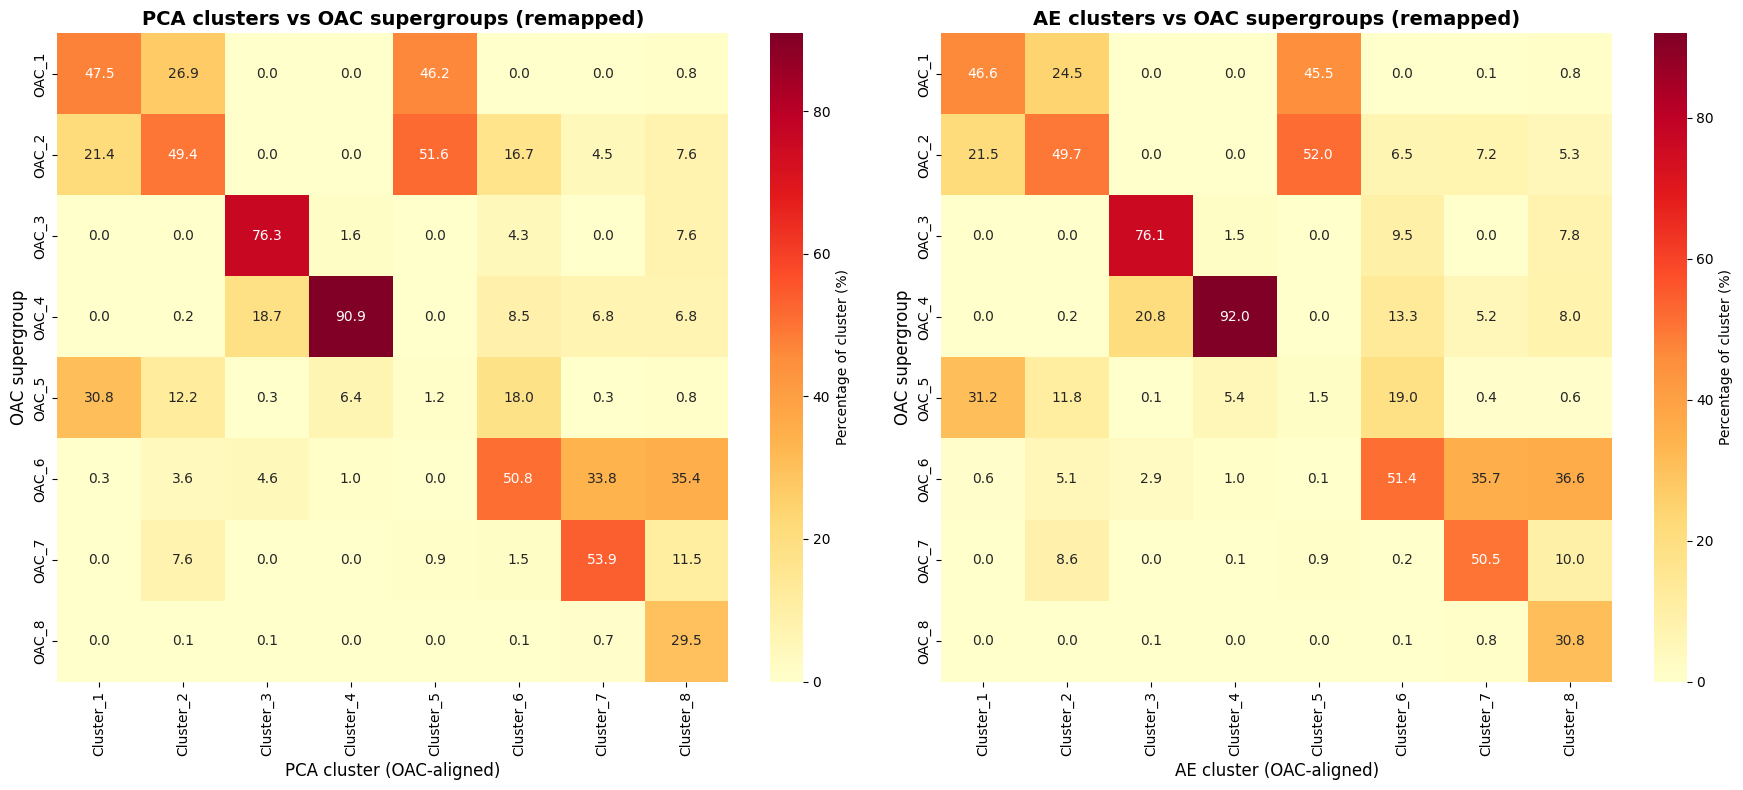


✓ Saved overlap matrices and remapping tables to ./plots/geodemo_clustering/
⚠️  All subsequent cells will use OAC-aligned cluster IDs!


In [ ]:
print("Computing cluster-to-OAC overlap matrices...\n")

def cluster_oac_overlap(cluster_labels, oac_labels, method_name, cluster_axis):
    """Return count and percentage matrices with clusters on the X-axis."""
    valid_mask = ~pd.isna(oac_labels)
    oac_valid = oac_labels[valid_mask]
    clusters_valid = cluster_labels[valid_mask]

    print(f"{method_name}: {valid_mask.sum():,} OAs with valid OAC labels")

    oac_ids = list(range(1, n_clusters + 1))
    counts = pd.crosstab(oac_valid, clusters_valid)
    counts = counts.reindex(index=oac_ids, columns=cluster_axis, fill_value=0)
    counts.index = [f'OAC_{oid}' for oid in counts.index]
    counts.columns = [f'Cluster_{cid}' for cid in counts.columns]

    percentages = counts.divide(counts.sum(axis=0).replace(0, np.nan), axis=1) * 100
    percentages = percentages.fillna(0)

    return counts, percentages

original_cluster_axis = list(range(n_clusters))
pca_counts, pca_percent = cluster_oac_overlap(pca_clusters, oac['Supergroup8'].values, 'PCA', original_cluster_axis)
ae_counts, ae_percent = cluster_oac_overlap(ae_clusters, oac['Supergroup8'].values, 'AE', original_cluster_axis)

print("\nPCA clusters → OAC distribution (% of cluster):")
print(pca_percent.round(1))
print("\nAE clusters → OAC distribution (% of cluster):")
print(ae_percent.round(1))

def greedy_one_to_one_mapping(counts_df):
    """Greedily assign each cluster to a unique OAC by highest overlap."""
    flattened = counts_df.stack().sort_values(ascending=False)
    cluster_mapping = {}
    used_oac = set()
    for (oac_label, cluster_label), value in flattened.items():
        cluster_id = int(cluster_label.split('_')[1])
        oac_id = int(oac_label.split('_')[1])
        if cluster_id not in cluster_mapping and oac_id not in used_oac:
            cluster_mapping[cluster_id] = oac_id
            used_oac.add(oac_id)
        if len(cluster_mapping) == counts_df.shape[1]:
            break

    remaining_clusters = sorted(set(range(counts_df.shape[1])) - set(cluster_mapping.keys()))
    remaining_oac = sorted(set(range(1, counts_df.shape[0] + 1)) - used_oac)
    for cluster_id, oac_id in zip(remaining_clusters, remaining_oac):
        cluster_mapping[cluster_id] = oac_id

    return cluster_mapping

pca_mapping = greedy_one_to_one_mapping(pca_counts)
ae_mapping = greedy_one_to_one_mapping(ae_counts)

print("\n" + "="*80)
print("Greedy one-to-one remapping (PCA clusters → OAC supergroups)")
print("="*80)
for cluster_id in sorted(pca_mapping.keys()):
    oac_id = pca_mapping[cluster_id]
    overlap = int(pca_counts.loc[f'OAC_{oac_id}', f'Cluster_{cluster_id}'])
    total = int(pca_counts[f'Cluster_{cluster_id}'].sum())
    pct = (overlap / total * 100) if total else 0.0
    print(f"  Cluster {cluster_id} → OAC {oac_id}: {overlap}/{total} OAs ({pct:.1f}%)")

print("\n" + "="*80)
print("Greedy one-to-one remapping (AE clusters → OAC supergroups)")
print("="*80)
for cluster_id in sorted(ae_mapping.keys()):
    oac_id = ae_mapping[cluster_id]
    overlap = int(ae_counts.loc[f'OAC_{oac_id}', f'Cluster_{cluster_id}'])
    total = int(ae_counts[f'Cluster_{cluster_id}'].sum())
    pct = (overlap / total * 100) if total else 0.0
    print(f"  Cluster {cluster_id} → OAC {oac_id}: {overlap}/{total} OAs ({pct:.1f}%)")

# Apply remapping to cluster assignments
pca_clusters_remapped = np.array([pca_mapping[c] for c in pca_clusters])
ae_clusters_remapped = np.array([ae_mapping[c] for c in ae_clusters])

# Update global state
clusters_df['pca_cluster'] = pca_clusters_remapped
clusters_df['ae_cluster'] = ae_clusters_remapped

if 'gdf' in locals():
    gdf['pca_cluster'] = pca_clusters_remapped
    gdf['ae_cluster'] = ae_clusters_remapped

pca_clusters = pca_clusters_remapped
ae_clusters = ae_clusters_remapped

# Recompute overlap matrices after remapping (clusters now 1..n_clusters)
remapped_cluster_axis = list(range(1, n_clusters + 1))
pca_counts_remap, pca_percent_remap = cluster_oac_overlap(pca_clusters, oac['Supergroup8'].values, 'PCA (remapped)', remapped_cluster_axis)
ae_counts_remap, ae_percent_remap = cluster_oac_overlap(ae_clusters, oac['Supergroup8'].values, 'AE (remapped)', remapped_cluster_axis)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(pca_percent_remap, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[0], cbar_kws={'label': 'Percentage of cluster (%)'})
axes[0].set_title('PCA clusters vs OAC supergroups (remapped)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('PCA cluster (OAC-aligned)', fontsize=12)
axes[0].set_ylabel('OAC supergroup', fontsize=12)

sns.heatmap(ae_percent_remap, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1], cbar_kws={'label': 'Percentage of cluster (%)'})
axes[1].set_title('AE clusters vs OAC supergroups (remapped)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('AE cluster (OAC-aligned)', fontsize=12)
axes[1].set_ylabel('OAC supergroup', fontsize=12)

plt.tight_layout()
plt.savefig(f"{output_dir}/cluster_oac_overlap_remapped_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

# Save mapping tables
pca_mapping_df = pd.DataFrame([
    {
        'original_cluster': cluster_id,
        'remapped_cluster': pca_mapping[cluster_id],
        'overlap_count': int(pca_counts.loc[f'OAC_{pca_mapping[cluster_id]}', f'Cluster_{cluster_id}']),
        'cluster_total': int(pca_counts[f'Cluster_{cluster_id}'].sum()),
        'overlap_pct': float(pca_percent.loc[f'OAC_{pca_mapping[cluster_id]}', f'Cluster_{cluster_id}'])
    }
    for cluster_id in sorted(pca_mapping.keys())
 ])
pca_mapping_df.to_csv(f"{output_dir}/pca_cluster_remapping_{target_dim}d.csv", index=False)

ae_mapping_df = pd.DataFrame([
    {
        'original_cluster': cluster_id,
        'remapped_cluster': ae_mapping[cluster_id],
        'overlap_count': int(ae_counts.loc[f'OAC_{ae_mapping[cluster_id]}', f'Cluster_{cluster_id}']),
        'cluster_total': int(ae_counts[f'Cluster_{cluster_id}'].sum()),
        'overlap_pct': float(ae_percent.loc[f'OAC_{ae_mapping[cluster_id]}', f'Cluster_{cluster_id}'])
    }
    for cluster_id in sorted(ae_mapping.keys())
 ])
ae_mapping_df.to_csv(f"{output_dir}/ae_cluster_remapping_{target_dim}d.csv", index=False)

# Save count/percentage matrices
pca_counts.to_csv(f"{output_dir}/pca_cluster_oac_overlap_counts_{target_dim}d.csv")
ae_counts.to_csv(f"{output_dir}/ae_cluster_oac_overlap_counts_{target_dim}d.csv")
pca_percent.to_csv(f"{output_dir}/pca_cluster_oac_overlap_percent_{target_dim}d.csv")
ae_percent.to_csv(f"{output_dir}/ae_cluster_oac_overlap_percent_{target_dim}d.csv")
pca_counts_remap.to_csv(f"{output_dir}/pca_cluster_oac_overlap_counts_remapped_{target_dim}d.csv")
ae_counts_remap.to_csv(f"{output_dir}/ae_cluster_oac_overlap_counts_remapped_{target_dim}d.csv")
pca_percent_remap.to_csv(f"{output_dir}/pca_cluster_oac_overlap_percent_remapped_{target_dim}d.csv")
ae_percent_remap.to_csv(f"{output_dir}/ae_cluster_oac_overlap_percent_remapped_{target_dim}d.csv")

print(f"\n✓ Saved overlap matrices and remapping tables to {output_dir}")
print("⚠️  All subsequent cells will use OAC-aligned cluster IDs!")

## Cluster Profiling

What are the demographic characteristics of each cluster?

In [ ]:
print("Profiling clusters using census variables...\n")

# Compute mean characteristics for each cluster
def profile_clusters(cluster_labels, method_name):
    profiles = []
    
    for cluster_id in range(n_clusters):
        mask = cluster_labels == cluster_id
        cluster_data = df_census[mask]
        
        # Mean values
        cluster_mean = cluster_data.mean()
        
        # Deviation from national mean
        national_mean = df_census.mean()
        deviation = ((cluster_mean - national_mean) / national_mean * 100)
        
        # Top 5 most distinctive variables (highest positive deviation)
        top_vars = deviation.nlargest(5)
        
        profiles.append({
            'cluster': cluster_id,
            'size': mask.sum(),
            'pct': mask.sum() / len(cluster_labels) * 100,
            'top_vars': list(top_vars.index),
            'top_deviations': list(top_vars.values)
        })
    
    profile_df = pd.DataFrame(profiles)
    
    print(f"{method_name} Cluster Profiles:")
    print("="*80)
    for _, row in profile_df.iterrows():
        print(f"\nCluster {row['cluster']}: {row['size']:,} OAs ({row['pct']:.1f}%)")
        print("  Top distinctive variables:")
        for var, dev in zip(row['top_vars'], row['top_deviations']):
            print(f"    {var}: {dev:+.1f}% vs national mean")
    
    return profile_df

pca_profiles = profile_clusters(pca_clusters, "PCA")
print("\n" + "="*80 + "\n")
ae_profiles = profile_clusters(ae_clusters, "AE")

# Save profiles
pca_profiles.to_csv(f"{output_dir}/pca_cluster_profiles_{target_dim}d.csv", index=False)
ae_profiles.to_csv(f"{output_dir}/ae_cluster_profiles_{target_dim}d.csv", index=False)
print(f"\n✓ Saved profiles to {output_dir}")

Profiling clusters using census variables...

PCA Cluster Profiles:

Cluster 0: 0 OAs (0.0%)
  Top distinctive variables:
    ts0010002: +nan% vs national mean
    ts0010003: +nan% vs national mean
    ts0020002: +nan% vs national mean
    ts0020003: +nan% vs national mean
    ts0020004: +nan% vs national mean

Cluster 1: 27,588 OAs (14.6%)
  Top distinctive variables:
    ts0510008: +185.9% vs national mean
    ts0510009: +184.3% vs national mean
    ts0440002: +171.9% vs national mean
    ts0510007: +154.5% vs national mean
    ts0510010: +144.3% vs national mean

Cluster 2: 44,673 OAs (23.7%)
  Top distinctive variables:
    ts0440003: +63.8% vs national mean
    ts0030006: +48.4% vs national mean
    ts0540003: +41.1% vs national mean
    ts007a0018: +39.0% vs national mean
    ts007a0017: +39.0% vs national mean

Cluster 3: 17,693 OAs (9.4%)
  Top distinctive variables:
    ts0050028: +458.8% vs national mean
    ts0460010: +457.8% vs national mean
    ts0510002: +417.1% vs nation

## Maps

Loading geometries for mapping...
GeoDataFrame: (188880, 4)


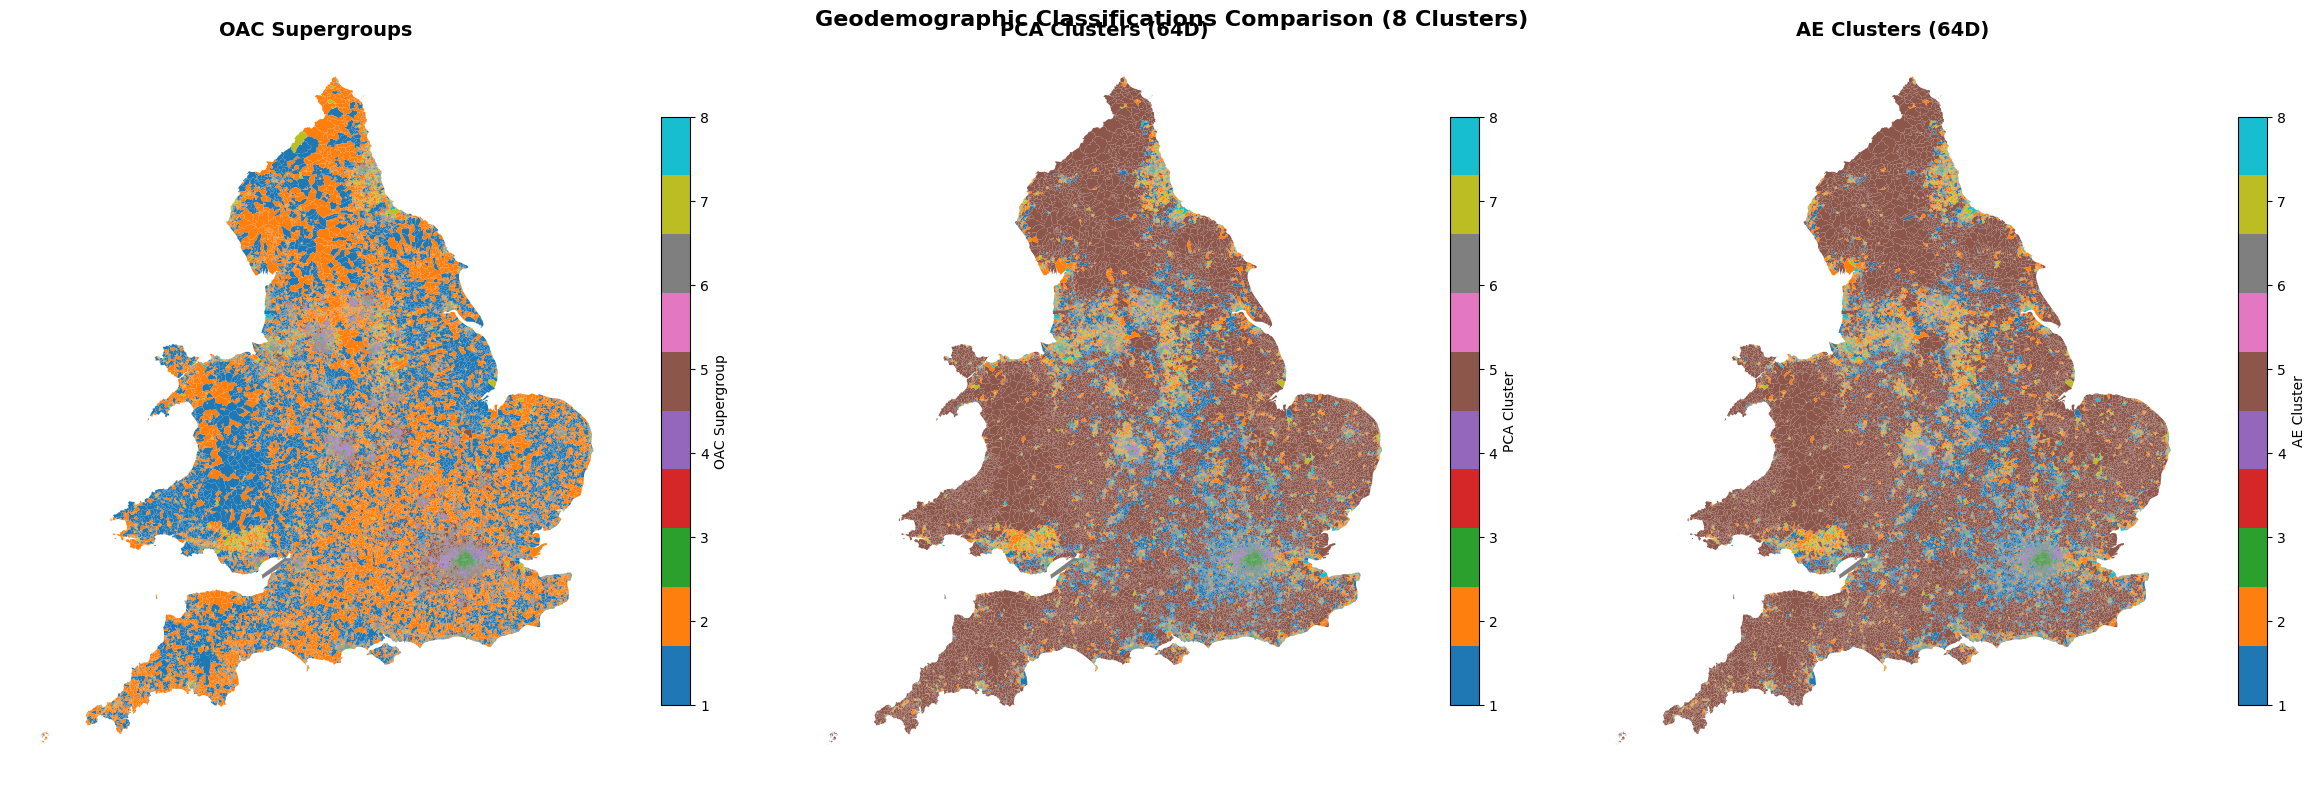

In [ ]:
# Load geometries
print("Loading geometries for mapping...")
gdf = gpd.read_file(geo_path)
gdf = gdf[['OA21CD', 'geometry']].rename(columns={'OA21CD': 'OA'})
gdf = gdf.set_index('OA')

# Merge with clusters
gdf = gdf.join(clusters_df)
print(f"GeoDataFrame: {gdf.shape}")

# Create side-by-side maps
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# OAC
gdf.plot(column='oac_supergroup', ax=axes[0], legend=True, 
         cmap='tab10', linewidth=0, edgecolor='none',
         legend_kwds={'label': 'OAC Supergroup', 'shrink': 0.8})
axes[0].set_title('OAC Supergroups', fontsize=14, fontweight='bold')
axes[0].axis('off')

# PCA
gdf.plot(column='pca_cluster', ax=axes[1], legend=True,
         cmap='tab10', linewidth=0, edgecolor='none',
         legend_kwds={'label': 'PCA Cluster', 'shrink': 0.8})
axes[1].set_title(f'PCA Clusters ({target_dim}D)', fontsize=14, fontweight='bold')
axes[1].axis('off')

# AE
gdf.plot(column='ae_cluster', ax=axes[2], legend=True,
         cmap='tab10', linewidth=0, edgecolor='none',
         legend_kwds={'label': 'AE Cluster', 'shrink': 0.8})
axes[2].set_title(f'AE Clusters ({target_dim}D)', fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.suptitle(f'Geodemographic Classifications Comparison ({n_clusters} Clusters)', 
             fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig(f"{output_dir}/classification_maps_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

Creating regional zoom maps...
London: 29,687 OAs
Cornwall: 1,918 OAs


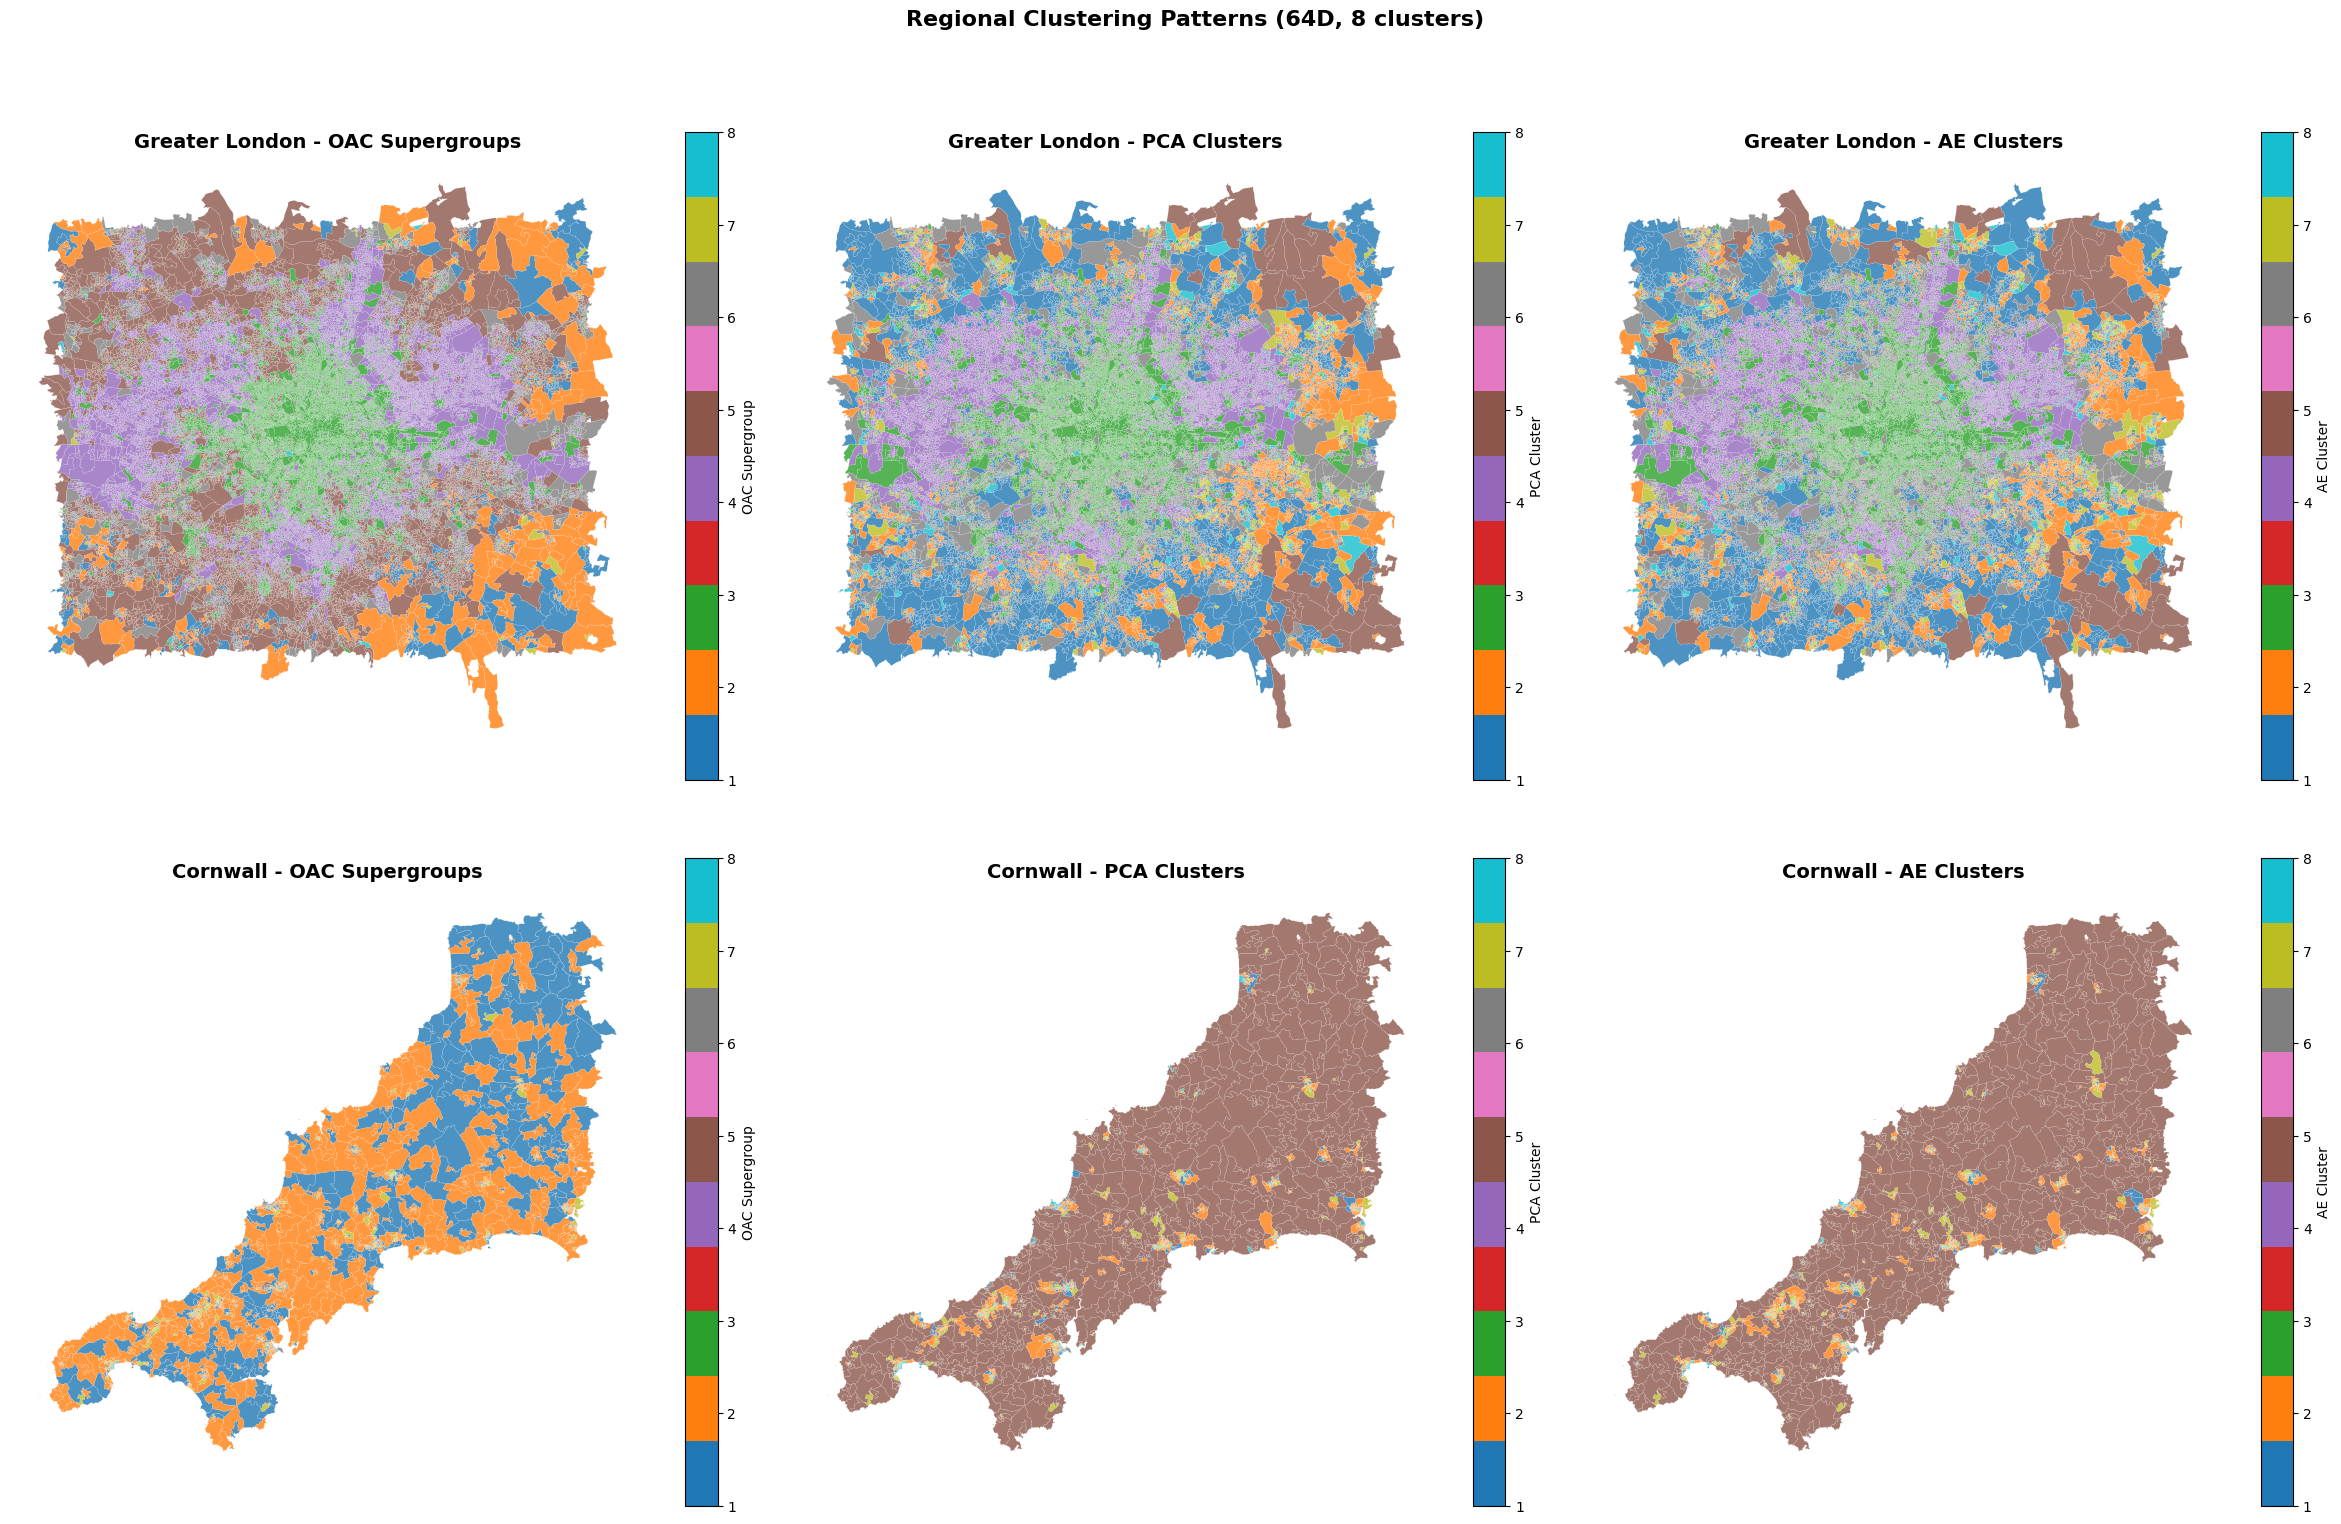


✓ Saved regional maps to ./plots/geodemo_clustering//regional_maps_64d.png


In [ ]:
# Regional zoom maps for London and Cornwall
print("Creating regional zoom maps...")

# Define bounding boxes (approximate)
regions = {
    'London': {
        'bounds': {'minx': -0.5, 'maxx': 0.3, 'miny': 51.3, 'maxy': 51.7},
        'title': 'Greater London'
    },
    'Cornwall': {
        'bounds': {'minx': -5.7, 'maxx': -4.2, 'miny': 50.0, 'maxy': 50.9},
        'title': 'Cornwall'
    }
}

# Create figure with 2 rows x 3 columns (OAC, PCA, AE)
fig, axes = plt.subplots(2, 3, figsize=(24, 16))

for row_idx, (region_name, region_info) in enumerate(regions.items()):
    # Filter to region using bounding box
    bounds = region_info['bounds']
    region_gdf = gdf.cx[bounds['minx']:bounds['maxx'], bounds['miny']:bounds['maxy']]

    print(f"{region_name}: {len(region_gdf):,} OAs")

    # OAC supergroups
    region_gdf.plot(column='oac_supergroup', ax=axes[row_idx, 0], legend=True,
                    cmap='tab10', linewidth=0.1, edgecolor='white', alpha=0.8,
                    legend_kwds={'label': 'OAC Supergroup', 'shrink': 0.8})
    axes[row_idx, 0].set_title(f'{region_info["title"]} - OAC Supergroups',
                                fontsize=14, fontweight='bold')
    axes[row_idx, 0].axis('off')

    # PCA clusters
    region_gdf.plot(column='pca_cluster', ax=axes[row_idx, 1], legend=True,
                    cmap='tab10', linewidth=0.1, edgecolor='white', alpha=0.8,
                    legend_kwds={'label': 'PCA Cluster', 'shrink': 0.8})
    axes[row_idx, 1].set_title(f'{region_info["title"]} - PCA Clusters',
                                fontsize=14, fontweight='bold')
    axes[row_idx, 1].axis('off')

    # AE clusters
    region_gdf.plot(column='ae_cluster', ax=axes[row_idx, 2], legend=True,
                    cmap='tab10', linewidth=0.1, edgecolor='white', alpha=0.8,
                    legend_kwds={'label': 'AE Cluster', 'shrink': 0.8})
    axes[row_idx, 2].set_title(f'{region_info["title"]} - AE Clusters',
                                fontsize=14, fontweight='bold')
    axes[row_idx, 2].axis('off')

plt.suptitle(f'Regional Clustering Patterns ({target_dim}D, {n_clusters} clusters)',
            fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f"{output_dir}/regional_maps_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved regional maps to {output_dir}/regional_maps_{target_dim}d.png")

In [ ]:
# Export cluster assignments with geometries for QGIS
print("Exporting cluster assignments to parquet for QGIS...")

# Prepare export geodataframe with all relevant columns
export_gdf = gdf[['geometry', 'pca_cluster', 'ae_cluster', 'oac_supergroup']].copy()

# Add cluster names/labels (optional but helpful)
export_gdf['pca_cluster_name'] = 'PCA_' + export_gdf['pca_cluster'].astype(str)
export_gdf['ae_cluster_name'] = 'AE_' + export_gdf['ae_cluster'].astype(str)
export_gdf['oac_name'] = 'OAC_' + export_gdf['oac_supergroup'].astype(str)

# Reset index to include OA code as a column
export_gdf = export_gdf.reset_index()

# Save to parquet (readable by QGIS 3.2+)
export_path = f"{output_dir}/cluster_assignments_with_geometry_{target_dim}d.parquet"
export_gdf.to_parquet(export_path)

print(f"✓ Saved {len(export_gdf):,} OAs to {export_path}")
print(f"\nColumns in export:")
print(f"  - OA: Output Area code")
print(f"  - geometry: Polygon geometry")
print(f"  - pca_cluster: PCA cluster ID (0-{n_clusters-1})")
print(f"  - ae_cluster: AE cluster ID (0-{n_clusters-1})")
print(f"  - oac_supergroup: OAC supergroup (1-8)")
print(f"  - pca_cluster_name: PCA cluster label")
print(f"  - ae_cluster_name: AE cluster label")
print(f"  - oac_name: OAC label")

Exporting cluster assignments to parquet for QGIS...
✓ Saved 188,880 OAs to ./plots/geodemo_clustering//cluster_assignments_with_geometry_64d.parquet

Columns in export:
  - OA: Output Area code
  - geometry: Polygon geometry
  - pca_cluster: PCA cluster ID (0-7)
  - ae_cluster: AE cluster ID (0-7)
  - oac_supergroup: OAC supergroup (1-8)
  - pca_cluster_name: PCA cluster label
  - ae_cluster_name: AE cluster label
  - oac_name: OAC label


## Summary

## Publication-Quality Maps

Create high-quality maps showing cluster assignments across the UK, with a London inset.

In [ ]:
# Step 1: Clip geometries (or load if already done)
import os
from tqdm import tqdm
import geopandas as gpd
output_dir ="./"
clipped_uk_path = f"{output_dir}/gdf_uk_clipped.parquet"
clipped_london_path = f"{output_dir}/gdf_london_clipped.parquet"
eng_wales_clipped_path = f"{output_dir}/eng_wales_clipped.parquet"

if os.path.exists(clipped_uk_path) and os.path.exists(clipped_london_path) and os.path.exists(eng_wales_clipped_path):
    print("Loading pre-clipped geometries...")
    gdf_uk_clipped = gpd.read_parquet(clipped_uk_path)
    gdf_london_clipped = gpd.read_parquet(clipped_london_path)
    eng_wales_clipped = gpd.read_parquet(eng_wales_clipped_path)
    
    # Still need London boundary for plotting
    lads_gdf = gpd.read_file("Local_Authority_Districts_December_2022_UK_BGC_V2_5759908710055972638.gpkg")
    london_boundary = lads_gdf[lads_gdf['LAD22CD'].str.startswith('E09')].dissolve()
    if london_boundary.crs != gdf.crs:
        london_boundary = london_boundary.to_crs(gdf.crs)
    
    # Recalculate London bounds
    minx, miny, maxx, maxy = london_boundary.total_bounds
    buffer = 0.05
    london_bounds = {
        'minx': minx - buffer, 
        'maxx': maxx + buffer, 
        'miny': miny - buffer, 
        'maxy': maxy + buffer
    }
    print("✓ Loaded clipped geometries")
    
else:
    print("Clipping geometries (this may take a while)...\n")
    
    # Load boundaries
    with tqdm(total=6, desc="Overall progress") as pbar:
        
        pbar.set_description("Loading country boundaries")
        countries_gdf = gpd.read_file("Countries_December_2022_UK_BGC_1943732719298389253.gpkg")
        eng_wales_gdf = countries_gdf[countries_gdf['CTRY22CD'].str.startswith(('E', 'W'))]
        england_gdf = countries_gdf[countries_gdf['CTRY22CD'].str.startswith('E')]
        pbar.update(1)
        
        pbar.set_description("Loading LADs")
        lads_gdf = gpd.read_file("Local_Authority_Districts_December_2022_UK_BGC_V2_5759908710055972638.gpkg")
        london_boundary = lads_gdf[lads_gdf['LAD22CD'].str.startswith('E09')].dissolve()
        pbar.update(1)
        
        pbar.set_description("Reprojecting")
        if eng_wales_gdf.crs != gdf.crs:
            eng_wales_gdf = eng_wales_gdf.to_crs(gdf.crs)
        if england_gdf.crs != gdf.crs:
            england_gdf = england_gdf.to_crs(gdf.crs)
        if london_boundary.crs != gdf.crs:
            london_boundary = london_boundary.to_crs(gdf.crs)
        pbar.update(1)
        
        # Create clip boxes
        from shapely.geometry import box
        oa_bounds = gdf.total_bounds
        clip_box = box(*oa_bounds)
        
        minx, miny, maxx, maxy = london_boundary.total_bounds
        buffer = 0.05
        london_bounds = {
            'minx': minx - buffer, 
            'maxx': maxx + buffer, 
            'miny': miny - buffer, 
            'maxy': maxy + buffer
        }
        
        pbar.set_description("Clipping country boundaries")
        eng_wales_clipped = eng_wales_gdf.clip(clip_box)
        pbar.update(1)
        
        pbar.set_description("Clipping UK OAs")
        gdf_uk_clipped = gdf.clip(clip_box)
        pbar.update(1)
        
        pbar.set_description("Clipping London OAs")
        gdf_london = gdf.cx[london_bounds['minx']:london_bounds['maxx'], 
                            london_bounds['miny']:london_bounds['maxy']]
        gdf_london_clipped = gdf_london.clip(england_gdf)
        pbar.update(1)
    
    # Save clipped data
    print("\nSaving clipped geometries...")
    gdf_uk_clipped.to_parquet(clipped_uk_path)
    gdf_london_clipped.to_parquet(clipped_london_path)
    eng_wales_clipped.to_parquet(eng_wales_clipped_path)
    print("✓ Saved clipped geometries for future use")

Clipping geometries (this may take a while)...



Reprojecting:  33%|███▎      | 2/6 [00:00<00:00, 15.30it/s]      


NameError: name 'gdf' is not defined

In [ ]:
# Create publication-quality maps with cluster labels
print("Creating publication-quality maps...\n")

# Load boundaries from local files
print("Loading UK country boundaries...")
countries_gdf = gpd.read_file("Countries_December_2022_UK_BGC_1943732719298389253.gpkg")

# Filter to England and Wales only
eng_wales_gdf = countries_gdf[countries_gdf['CTRY22CD'].str.startswith(('E', 'W'))]

# Get England boundary for clipping London
england_gdf = countries_gdf[countries_gdf['CTRY22CD'].str.startswith('E')]

print("Loading Local Authority Districts...")
lads_gdf = gpd.read_file("Local_Authority_Districts_December_2022_UK_BGC_V2_5759908710055972638.gpkg")

# Create Greater London boundary by dissolving London boroughs (E09 codes)
london_boundary = lads_gdf[lads_gdf['LAD22CD'].str.startswith('E09')].dissolve()

print("Boundaries loaded successfully!")

# Ensure CRS matches
if eng_wales_gdf.crs != gdf.crs:
    eng_wales_gdf = eng_wales_gdf.to_crs(gdf.crs)
if england_gdf.crs != gdf.crs:
    england_gdf = england_gdf.to_crs(gdf.crs)
if london_boundary.crs != gdf.crs:
    london_boundary = london_boundary.to_crs(gdf.crs)

# Clip country boundaries to the extent of the OA data
from shapely.geometry import box
oa_bounds = gdf.total_bounds  # minx, miny, maxx, maxy
clip_box = box(*oa_bounds)
eng_wales_clipped = eng_wales_gdf.clip(clip_box)

# Get London bounds from the actual boundary with a small buffer
minx, miny, maxx, maxy = london_boundary.total_bounds
buffer = 0.05
london_bounds = {
    'minx': minx - buffer, 
    'maxx': maxx + buffer, 
    'miny': miny - buffer, 
    'maxy': maxy + buffer
}

# Create clip box for London view (intersection of London bounds and England)
london_clip_box = box(london_bounds['minx'], london_bounds['miny'], 
                      london_bounds['maxx'], london_bounds['maxy'])

# Clip OA data to the bounds for each map
print("Clipping geometries...")
gdf_uk_clipped = gdf.clip(clip_box)
gdf_london_clipped = gdf.clip(london_clip_box).clip(england_gdf)

# Create figure with 1 row, 2 columns (London is 1/3 width)
fig, (ax_uk, ax_ldn) = plt.subplots(1, 2, figsize=(16, 8), 
                                      gridspec_kw={'width_ratios': [2, 1]})

# Color map
cmap = plt.cm.get_cmap('tab10', n_clusters)

# AE - UK-wide
gdf_uk_clipped.plot(column='ae_cluster', ax=ax_uk, cmap=cmap,
                    linewidth=0, edgecolor='none', legend=False)
# Add England and Wales borders (clipped to OA extent)
eng_wales_clipped.boundary.plot(ax=ax_uk, linewidth=0.8, edgecolor='black', alpha=0.7)
ax_uk.axis('off')

# AE - London (clipped to England)
gdf_london_clipped.plot(column='ae_cluster', ax=ax_ldn, cmap=cmap,
                        linewidth=0, edgecolor='none', legend=False)
# Add Greater London boundary
london_boundary.boundary.plot(ax=ax_ldn, linewidth=1.2, edgecolor='black', alpha=0.8)
ax_ldn.set_xlim(london_bounds['minx'], london_bounds['maxx'])
ax_ldn.set_ylim(london_bounds['miny'], london_bounds['maxy'])
ax_ldn.axis('off')

# Add borders around each subplot
for ax in [ax_uk, ax_ldn]:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.5)
        spine.set_edgecolor('black')

# Custom legend with simple numbers
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=cmap(i-1), label=str(i)) 
                   for i in range(1, n_clusters + 1)]
fig.legend(handles=legend_elements, loc='lower center', ncol=n_clusters, 
           fontsize=12, frameon=False,
           bbox_to_anchor=(0.7, 0.02), title='Cluster ID', title_fontsize=12)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(f"{output_dir}/publication_map_ae_{target_dim}d.png", 
            dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print(f"✓ Saved publication-quality map to {output_dir}/publication_map_ae_{target_dim}d.png")

Creating publication-quality maps...

Loading UK country boundaries...
Loading Local Authority Districts...
Boundaries loaded successfully!


NameError: name 'gdf' is not defined

## OAC Overlap Analysis

Publication-quality table showing the overlap between learned clusters and OAC supergroups.

In [ ]:
# Create publication-quality OAC overlap table
print("Creating OAC overlap table...\n")

# Create formatted table for AE clusters
ae_overlap_styled = ae_percent_remap.copy()

# Add OAC names to index
ae_overlap_styled.index = [f"OAC {i}: {oac_names[i].replace(chr(10), ' ')}" 
                           for i in range(1, n_clusters + 1)]

# Display styled table
print("\n" + "="*100)
print("AE CLUSTER OVERLAP WITH OAC SUPERGROUPS (% of each cluster)")
print("="*100)
print("\nEach cell shows what percentage of the cluster (column) belongs to each OAC supergroup (row).")
print("Clusters have been aligned to OAC supergroups using greedy one-to-one mapping.\n")

styled_table = ae_overlap_styled.style.background_gradient(
    cmap='YlOrRd', axis=None, vmin=0, vmax=100
).format("{:.1f}%").set_properties(**{
    'text-align': 'center',
    'font-size': '11pt'
}).set_table_styles([
    {'selector': 'th', 'props': [('font-size', '12pt'), ('font-weight', 'bold'), 
                                  ('text-align', 'center')]},
    {'selector': 'td', 'props': [('padding', '8px')]}
])

display(styled_table)

# Print summary statistics
print("\n" + "="*100)
print("SUMMARY: Maximum overlap per cluster (diagonal alignment)")
print("="*100)
for i in range(1, n_clusters + 1):
    col_name = f'Cluster_{i}'
    row_name = f'OAC_{i}'
    diagonal_value = ae_percent_remap.loc[row_name, col_name]
    print(f"  Cluster {i} ↔ {oac_names[i]}: {diagonal_value:.1f}% overlap")

print(f"\nMean diagonal overlap: {np.diag(ae_percent_remap.values).mean():.1f}%")
print(f"\nAdjusted Rand Index (AE vs OAC): {ari_ae:.4f}")
print(f"V-Measure Score (AE vs OAC): {v_ae:.4f}")

# Also create comparison table for PCA
print("\n\n" + "="*100)
print("PCA CLUSTER OVERLAP WITH OAC SUPERGROUPS (% of each cluster)")
print("="*100)

pca_overlap_styled = pca_percent_remap.copy()
pca_overlap_styled.index = [f"OAC {i}: {oac_names[i].replace(chr(10), ' ')}" 
                            for i in range(1, n_clusters + 1)]

styled_table_pca = pca_overlap_styled.style.background_gradient(
    cmap='YlOrRd', axis=None, vmin=0, vmax=100
).format("{:.1f}%").set_properties(**{
    'text-align': 'center',
    'font-size': '11pt'
}).set_table_styles([
    {'selector': 'th', 'props': [('font-size', '12pt'), ('font-weight', 'bold'), 
                                  ('text-align', 'center')]},
    {'selector': 'td', 'props': [('padding', '8px')]}
])

display(styled_table_pca)

print(f"\nMean diagonal overlap: {np.diag(pca_percent_remap.values).mean():.1f}%")
print(f"\nAdjusted Rand Index (PCA vs OAC): {ari_pca:.4f}")
print(f"V-Measure Score (PCA vs OAC): {v_pca:.4f}")

print("\n✓ OAC overlap analysis complete")

## Cluster Center Decoding Analysis

**Goal**: Test if averaging in latent space produces meaningful cluster prototypes.

**Method**:
1. Compute cluster centers in latent space (mean of embeddings per cluster)
2. Decode these centers back to 408D:
   - PCA: Use inverse_transform()
   - AE: Pass through decoder network
3. Compare decoded centers vs actual means of original data for each cluster

**Expected Result**:
- PCA should match perfectly (linearity)
- AE may have small discrepancies (non-linearity)
- Small discrepancies → latent space preserves cluster structure well

In [ ]:
import torch
import torch.nn as nn
from scipy.stats import pearsonr

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.7.1+cu126
CUDA available: True


### Import Autoencoder Architecture

In [ ]:
# Import the AutoEncoder class from torchgeodemo package
from torchgeodemo.models import AutoEncoder

print(f"✓ Imported AutoEncoder from torchgeodemo.models")
print(f"  This is the same architecture used to train the models")

✓ Imported AutoEncoder from torchgeodemo.models
  This is the same architecture used to train the models


### Load Trained Autoencoder Model

In [ ]:
# Load trained AE model
input_dim = df_census.shape[1]  # 408 variables
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load model from checkpoint
model_path = f"{working_dir}/census_geodemo__bottleneck_{target_dim}_v1__model.pth"
print(f"Looking for model at: {model_path}")

if os.path.exists(model_path):
    # Load the full model object (saved with torch.save(model, path))
    ae_model = torch.load(model_path, map_location=device, weights_only=False)
    ae_model.eval()
    print(f"✓ Loaded pre-trained AE model ({target_dim}D)")
    print(f"  Model type: {type(ae_model).__name__}")
    print(f"  Device: {device}")
else:
    print(f"⚠ Model file not found at {model_path}")
    print("  Note: This analysis requires the trained model file, not just embeddings")
    print("  You may need to re-run notebook 2 with model saving enabled")
    raise FileNotFoundError(f"Model not found: {model_path}")

Looking for model at: ../AE_outputs/engcensus_all/250epoch_scan_lin/census_geodemo__bottleneck_64_v1__model.pth
✓ Loaded pre-trained AE model (64D)
  Model type: AutoEncoder
  Device: cuda


### Compute Cluster Centers in Latent Space

In [ ]:
print("Computing cluster centers in latent space...\n")

# Get cluster centers from KMeans (already computed during clustering)
pca_cluster_centers = kmeans_pca.cluster_centers_  # shape: (n_clusters, target_dim)
ae_cluster_centers = kmeans_ae.cluster_centers_    # shape: (n_clusters, target_dim)

print(f"PCA cluster centers: {pca_cluster_centers.shape}")
print(f"AE cluster centers: {ae_cluster_centers.shape}")

# Also compute actual means in original space for each cluster
pca_actual_means = np.zeros((n_clusters, input_dim))
ae_actual_means = np.zeros((n_clusters, input_dim))

for cluster_id in range(n_clusters):
    # PCA cluster actual mean
    pca_mask = pca_clusters == cluster_id
    pca_actual_means[cluster_id] = df_census[pca_mask].mean().values
    
    # AE cluster actual mean
    ae_mask = ae_clusters == cluster_id
    ae_actual_means[cluster_id] = df_census[ae_mask].mean().values

print(f"\nPCA actual means: {pca_actual_means.shape}")
print(f"AE actual means: {ae_actual_means.shape}")

Computing cluster centers in latent space...

PCA cluster centers: (8, 64)
AE cluster centers: (8, 64)

PCA actual means: (8, 408)
AE actual means: (8, 408)


### Decode Cluster Centers Back to Original Space

In [ ]:
print("Decoding cluster centers back to 408D...\n")

# PCA: Use inverse_transform
print("PCA inverse transform...")
pca_decoded_centers = pca.inverse_transform(pca_cluster_centers)
print(f"  PCA decoded centers: {pca_decoded_centers.shape}")

# AE: Pass through decoder
print("\nAE decoder...")
with torch.no_grad():
    ae_centers_tensor = torch.FloatTensor(ae_cluster_centers).to(device)
    ae_decoded_centers = ae_model.decoder(ae_centers_tensor).cpu().numpy()
print(f"  AE decoded centers: {ae_decoded_centers.shape}")

print(f"\n✓ Decoded {n_clusters} cluster centers for both methods")

Decoding cluster centers back to 408D...

PCA inverse transform...
  PCA decoded centers: (8, 408)

AE decoder...
  AE decoded centers: (8, 408)

✓ Decoded 8 cluster centers for both methods


### Compute Discrepancy Metrics

In [ ]:
print("="*80)
print("CLUSTER CENTER DECODING METRICS")
print("="*80)

# Compute metrics for each cluster
pca_metrics = []
ae_metrics = []

for cluster_id in range(n_clusters):
    # PCA metrics
    pca_decoded = pca_decoded_centers[cluster_id]
    pca_actual = pca_actual_means[cluster_id]
    pca_rmse = np.sqrt(np.mean((pca_decoded - pca_actual)**2))
    pca_corr, _ = pearsonr(pca_decoded, pca_actual)
    pca_metrics.append({'cluster': cluster_id, 'rmse': pca_rmse, 'correlation': pca_corr})
    
    # AE metrics
    ae_decoded = ae_decoded_centers[cluster_id]
    ae_actual = ae_actual_means[cluster_id]
    ae_rmse = np.sqrt(np.mean((ae_decoded - ae_actual)**2))
    ae_corr, _ = pearsonr(ae_decoded, ae_actual)
    ae_metrics.append({'cluster': cluster_id, 'rmse': ae_rmse, 'correlation': ae_corr})

# Convert to DataFrames
pca_metrics_df = pd.DataFrame(pca_metrics)
ae_metrics_df = pd.DataFrame(ae_metrics)

# Overall metrics
pca_mean_rmse = pca_metrics_df['rmse'].mean()
ae_mean_rmse = ae_metrics_df['rmse'].mean()
pca_mean_corr = pca_metrics_df['correlation'].mean()
ae_mean_corr = ae_metrics_df['correlation'].mean()

print(f"\nPCA (decoded center vs actual mean):")
print(f"  Mean RMSE: {pca_mean_rmse:.6f}")
print(f"  Mean Correlation: {pca_mean_corr:.6f}")
print(f"  RMSE range: [{pca_metrics_df['rmse'].min():.6f}, {pca_metrics_df['rmse'].max():.6f}]")
print(f"  Corr range: [{pca_metrics_df['correlation'].min():.6f}, {pca_metrics_df['correlation'].max():.6f}]")

print(f"\nAE (decoded center vs actual mean):")
print(f"  Mean RMSE: {ae_mean_rmse:.6f}")
print(f"  Mean Correlation: {ae_mean_corr:.6f}")
print(f"  RMSE range: [{ae_metrics_df['rmse'].min():.6f}, {ae_metrics_df['rmse'].max():.6f}]")
print(f"  Corr range: [{ae_metrics_df['correlation'].min():.6f}, {ae_metrics_df['correlation'].max():.6f}]")

print(f"\nComparison:")
print(f"  RMSE ratio (AE/PCA): {ae_mean_rmse / pca_mean_rmse:.2f}x")
print(f"  Correlation difference (AE - PCA): {ae_mean_corr - pca_mean_corr:+.6f}")

# Per-cluster breakdown
print(f"\n{'='*80}")
print("PER-CLUSTER METRICS")
print(f"{'='*80}")

comparison_df = pd.DataFrame({
    'Cluster': range(n_clusters),
    'PCA_RMSE': pca_metrics_df['rmse'],
    'AE_RMSE': ae_metrics_df['rmse'],
    'PCA_Corr': pca_metrics_df['correlation'],
    'AE_Corr': ae_metrics_df['correlation']
})
print(comparison_df.to_string(index=False))

# Save metrics
comparison_df.to_csv(f"{output_dir}/data/cluster_center_decoding_metrics_{target_dim}d.csv", index=False)
print(f"\n✓ Saved metrics to {output_dir}/data/cluster_center_decoding_metrics_{target_dim}d.csv")

CLUSTER CENTER DECODING METRICS

PCA (decoded center vs actual mean):
  Mean RMSE: 0.000479
  Mean Correlation: 0.999997
  RMSE range: [0.000274, 0.000670]
  Corr range: [0.999995, 0.999999]

AE (decoded center vs actual mean):
  Mean RMSE: 0.003976
  Mean Correlation: 0.999820
  RMSE range: [0.002808, 0.005327]
  Corr range: [0.999639, 0.999930]

Comparison:
  RMSE ratio (AE/PCA): 8.30x
  Correlation difference (AE - PCA): -0.000177

PER-CLUSTER METRICS
 Cluster  PCA_RMSE  AE_RMSE  PCA_Corr  AE_Corr
       0  0.000604 0.004600  0.999995 0.999802
       1  0.000274 0.004185  0.999999 0.999814
       2  0.000439 0.003847  0.999998 0.999798
       3  0.000557 0.004091  0.999996 0.999819
       4  0.000539 0.003781  0.999997 0.999849
       5  0.000282 0.005327  0.999999 0.999639
       6  0.000670 0.002808  0.999995 0.999930
       7  0.000469 0.003168  0.999998 0.999905

✓ Saved metrics to ./plots/geodemo_clustering//data/cluster_center_decoding_metrics_64d.csv


### Visualization: Per-Cluster RMSE Comparison

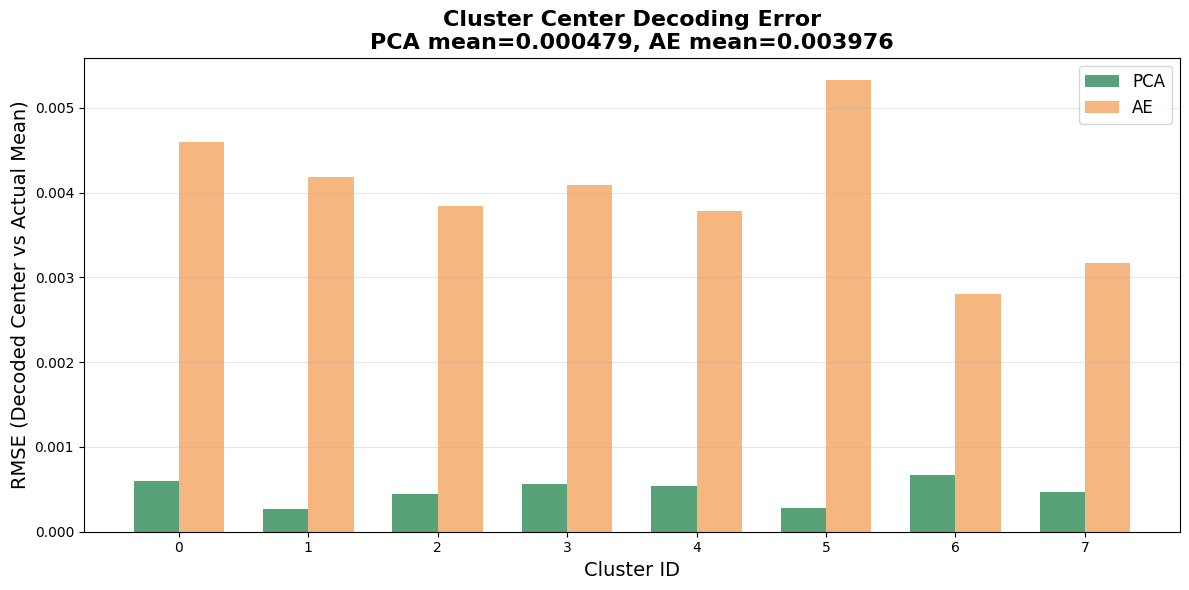

✓ Saved RMSE bar chart


In [ ]:
# Bar chart: Per-cluster RMSE
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(n_clusters)
width = 0.35

ax.bar(x - width/2, pca_metrics_df['rmse'], width, label='PCA', color='seagreen', alpha=0.8)
ax.bar(x + width/2, ae_metrics_df['rmse'], width, label='AE', color='sandybrown', alpha=0.8)

ax.set_xlabel('Cluster ID', fontsize=14)
ax.set_ylabel('RMSE (Decoded Center vs Actual Mean)', fontsize=14)
ax.set_title(f'Cluster Center Decoding Error\nPCA mean={pca_mean_rmse:.6f}, AE mean={ae_mean_rmse:.6f}', 
             fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"{output_dir}/cluster_center_rmse_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved RMSE bar chart")

### Visualization: Decoded vs Actual Scatter Plots (First 2 Clusters)

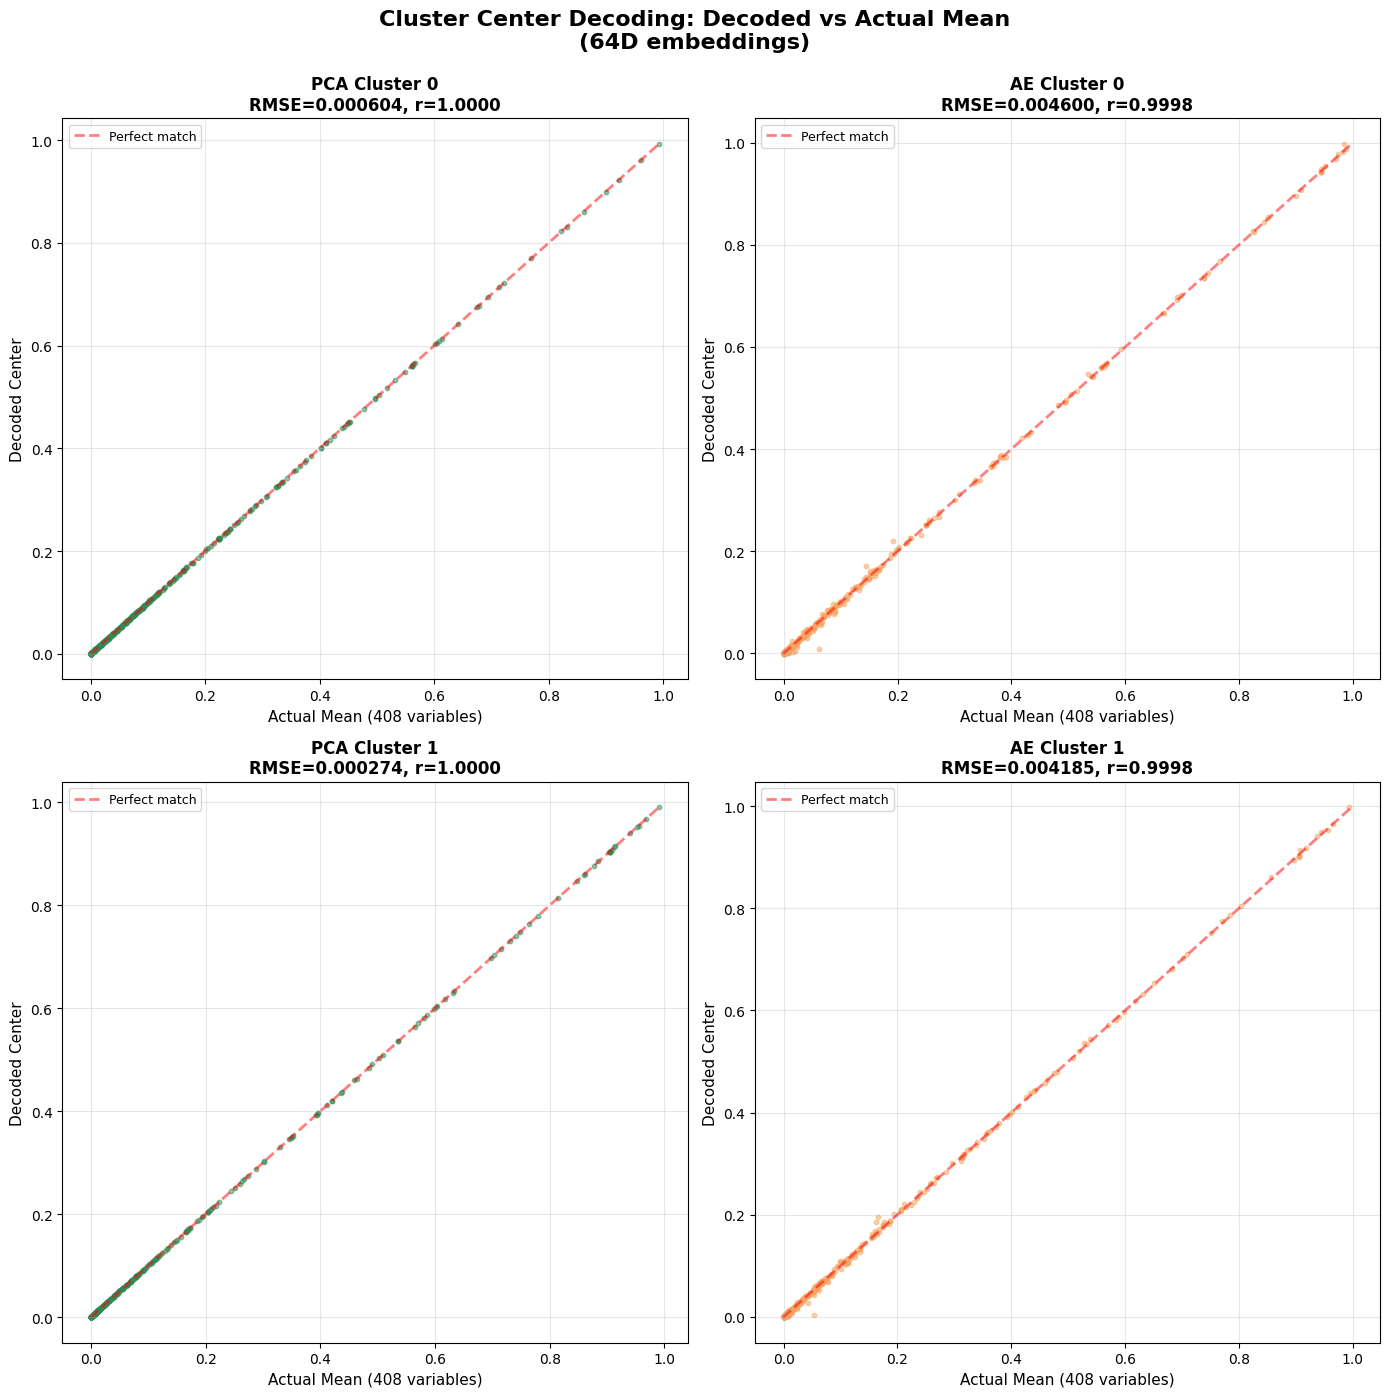

✓ Saved scatter plots


In [ ]:
# Scatter plots for first 2 clusters as examples
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

for cluster_idx in range(min(2, n_clusters)):
    # PCA
    ax_pca = axes[cluster_idx, 0]
    pca_decoded = pca_decoded_centers[cluster_idx]
    pca_actual = pca_actual_means[cluster_idx]
    
    ax_pca.scatter(pca_actual, pca_decoded, alpha=0.5, s=10, color='seagreen')
    lims = [min(pca_actual.min(), pca_decoded.min()), max(pca_actual.max(), pca_decoded.max())]
    ax_pca.plot(lims, lims, 'r--', alpha=0.5, linewidth=2, label='Perfect match')
    ax_pca.set_xlabel('Actual Mean (408 variables)', fontsize=11)
    ax_pca.set_ylabel('Decoded Center', fontsize=11)
    ax_pca.set_title(f'PCA Cluster {cluster_idx}\nRMSE={pca_metrics_df.iloc[cluster_idx]["rmse"]:.6f}, r={pca_metrics_df.iloc[cluster_idx]["correlation"]:.4f}',
                     fontsize=12, fontweight='bold')
    ax_pca.legend(fontsize=9)
    ax_pca.grid(True, alpha=0.3)
    
    # AE
    ax_ae = axes[cluster_idx, 1]
    ae_decoded = ae_decoded_centers[cluster_idx]
    ae_actual = ae_actual_means[cluster_idx]
    
    ax_ae.scatter(ae_actual, ae_decoded, alpha=0.5, s=10, color='sandybrown')
    lims = [min(ae_actual.min(), ae_decoded.min()), max(ae_actual.max(), ae_decoded.max())]
    ax_ae.plot(lims, lims, 'r--', alpha=0.5, linewidth=2, label='Perfect match')
    ax_ae.set_xlabel('Actual Mean (408 variables)', fontsize=11)
    ax_ae.set_ylabel('Decoded Center', fontsize=11)
    ax_ae.set_title(f'AE Cluster {cluster_idx}\nRMSE={ae_metrics_df.iloc[cluster_idx]["rmse"]:.6f}, r={ae_metrics_df.iloc[cluster_idx]["correlation"]:.4f}',
                     fontsize=12, fontweight='bold')
    ax_ae.legend(fontsize=9)
    ax_ae.grid(True, alpha=0.3)

plt.suptitle(f'Cluster Center Decoding: Decoded vs Actual Mean\n({target_dim}D embeddings)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f"{output_dir}/cluster_center_scatter_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved scatter plots")

NameError: name 'var_mean_error' is not defined

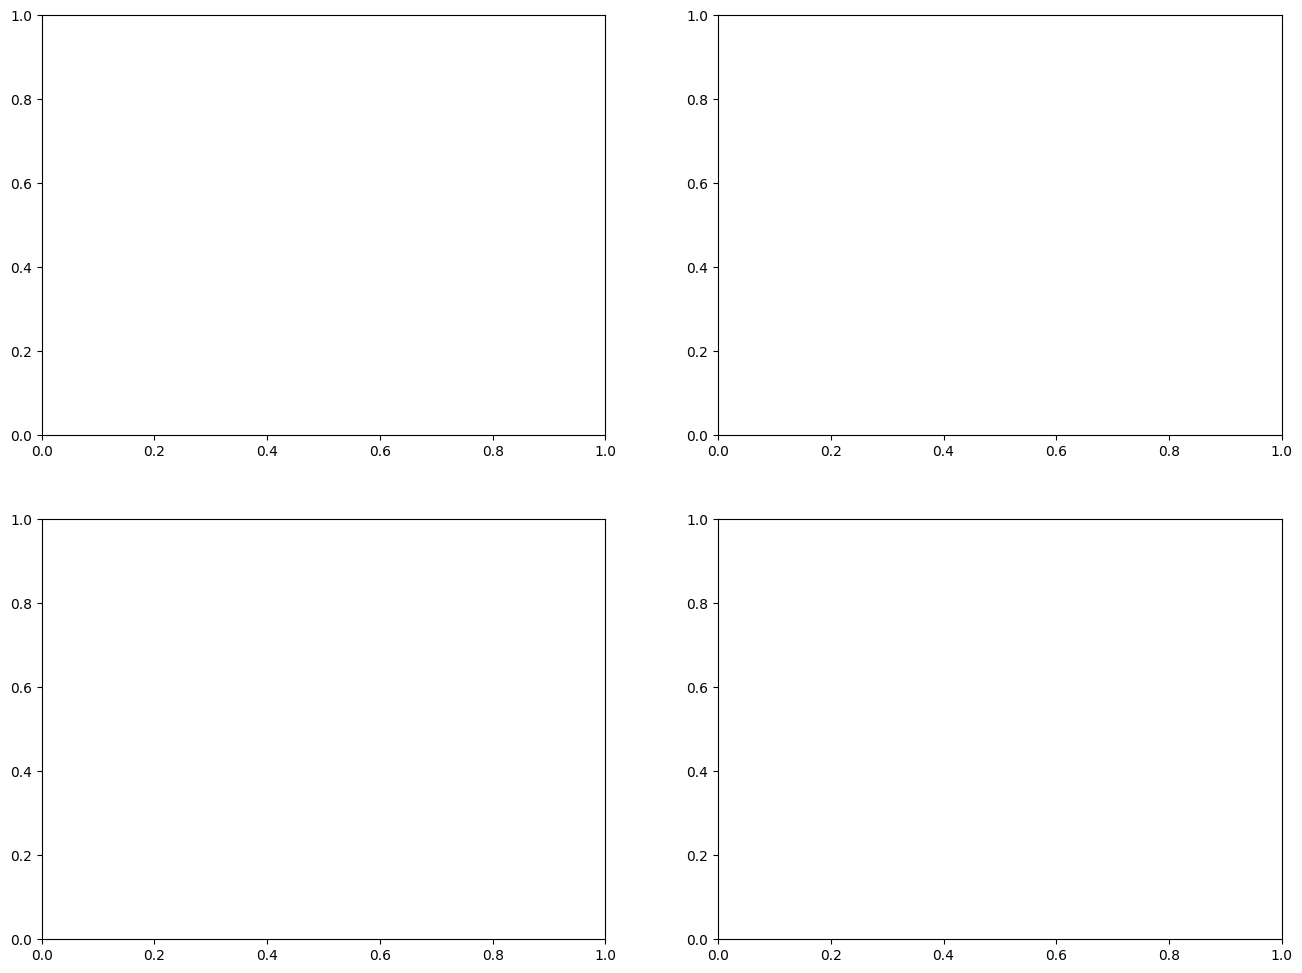

In [ ]:
# Create comprehensive visualization of per-variable errors
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Histogram of mean errors
ax1 = axes[0, 0]
ax1.hist(var_mean_error, bins=50, color='sandybrown', alpha=0.7, edgecolor='black')
ax1.axvline(var_mean_error.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {var_mean_error.mean():.6f}')
ax1.axvline(np.median(var_mean_error), color='blue', linestyle='--', linewidth=2,
            label=f'Median: {np.median(var_mean_error):.6f}')
ax1.set_xlabel('Mean Absolute Error', fontsize=12)
ax1.set_ylabel('Number of Variables', fontsize=12)
ax1.set_title('Distribution of Variable-Level Errors\n(AE Cluster Center Decoding)', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# 2. Top 30 worst variables
ax2 = axes[0, 1]
top_worst = var_analysis_sorted.head(30)
y_pos = np.arange(len(top_worst))
ax2.barh(y_pos, top_worst['mean_error'].values, color='coral', alpha=0.7)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(top_worst['variable'].values, fontsize=8)
ax2.invert_yaxis()
ax2.set_xlabel('Mean Absolute Error', fontsize=12)
ax2.set_title('Top 30 Worst Reconstructed Variables', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

# 3. Error vs Mean Value scatter
ax3 = axes[1, 0]
scatter = ax3.scatter(var_analysis['mean_value'], var_analysis['mean_error'], 
                     alpha=0.5, s=20, c=var_analysis['std_value'], 
                     cmap='viridis', edgecolors='black', linewidth=0.5)
ax3.set_xlabel('Variable Mean Value', fontsize=12)
ax3.set_ylabel('Mean Absolute Error', fontsize=12)
ax3.set_title('Error vs Variable Mean Value\n(color = std dev)', 
              fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax3)
cbar.set_label('Std Dev', fontsize=10)

# 4. Heatmap of errors across clusters (top 30 worst vars)
ax4 = axes[1, 1]
worst_var_indices = var_analysis_sorted.head(30).index
heatmap_data = var_rmse_matrix[:, worst_var_indices].T
im = ax4.imshow(heatmap_data, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax4.set_yticks(np.arange(30))
ax4.set_yticklabels([var_names[i][:20] for i in worst_var_indices], fontsize=8)
ax4.set_xticks(np.arange(n_clusters))
ax4.set_xticklabels([f'C{i}' for i in range(n_clusters)])
ax4.set_xlabel('Cluster', fontsize=12)
ax4.set_ylabel('Variable (Top 30 Worst)', fontsize=12)
ax4.set_title('Error Heatmap by Cluster\n(Top 30 Worst Variables)', 
              fontsize=13, fontweight='bold')
cbar2 = plt.colorbar(im, ax=ax4)
cbar2.set_label('Absolute Error', fontsize=10)

plt.tight_layout()
plt.savefig(f"{output_dir}/ae_variable_error_analysis_{target_dim}d.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved variable error visualization to {output_dir}/ae_variable_error_analysis_{target_dim}d.png")

### Interpretation

In [ ]:
print("="*80)
print("INTERPRETATION: CLUSTER CENTER DECODING")
print("="*80)

print(f"\n📊 What This Tests:")
print(f"  Does averaging in latent space produce meaningful cluster prototypes?")
print(f"  decode(cluster_center) ≈ mean(original_data_in_cluster)")

print(f"\n📈 Results:")

# PCA interpretation
if pca_mean_rmse < 0.01:
    print(f"\n✓ PCA: EXCELLENT (RMSE={pca_mean_rmse:.6f})")
    print(f"  Near-perfect match as expected due to linearity")
elif pca_mean_rmse < 0.05:
    print(f"\n✓ PCA: GOOD (RMSE={pca_mean_rmse:.6f})")
    print(f"  Small errors due to dimensionality reduction ({target_dim}D vs 408D)")
else:
    print(f"\n⚠ PCA: MODERATE (RMSE={pca_mean_rmse:.6f})")
    print(f"  Larger than expected - may need higher dimensions")

# AE interpretation
if ae_mean_rmse < 0.05:
    print(f"\n✓ AE: EXCELLENT (RMSE={ae_mean_rmse:.6f})")
    print(f"  Latent space is locally linear around cluster centers")
    print(f"  Cluster centers represent valid prototypical OAs")
elif ae_mean_rmse < 0.10:
    print(f"\n✓ AE: GOOD (RMSE={ae_mean_rmse:.6f})")
    print(f"  Acceptable non-linearity effects")
    print(f"  Cluster centers are still meaningful")
else:
    print(f"\n⚠ AE: MODERATE (RMSE={ae_mean_rmse:.6f})")
    print(f"  Non-linearity warps cluster structure significantly")
    print(f"  Cluster centers less interpretable as prototypes")

# Comparison
ratio = ae_mean_rmse / pca_mean_rmse
print(f"\n💡 AE vs PCA Comparison:")
print(f"  RMSE ratio (AE/PCA): {ratio:.2f}x")
if ratio < 2:
    print(f"  ✓ AE preserves prototype quality despite non-linearity")
    print(f"    Cluster centers in latent space are valid prototypes")
elif ratio < 5:
    print(f"  ⚠ AE has moderate prototype degradation")
    print(f"    Non-linearity affects cluster center interpretability")
else:
    print(f"  ✗ AE has significant prototype degradation")
    print(f"    Cluster centers in latent space poorly represent actual data")

print(f"\n🎯 Conclusion:")
if ratio < 2 and ae_mean_corr > 0.95:
    print(f"  The {target_dim}D latent space (both AE and PCA) produces valid cluster prototypes.")
    print(f"  Cluster centers can be decoded to interpret demographic profiles.")
else:
    print(f"  Cluster centers should be interpreted with caution.")
    print(f"  Consider using actual cluster means instead of decoded centers.")

print("\n" + "="*80)

INTERPRETATION: CLUSTER CENTER DECODING

📊 What This Tests:
  Does averaging in latent space produce meaningful cluster prototypes?
  decode(cluster_center) ≈ mean(original_data_in_cluster)

📈 Results:

✓ PCA: EXCELLENT (RMSE=0.000479)
  Near-perfect match as expected due to linearity

✓ AE: EXCELLENT (RMSE=0.003976)
  Latent space is locally linear around cluster centers
  Cluster centers represent valid prototypical OAs

💡 AE vs PCA Comparison:
  RMSE ratio (AE/PCA): 8.30x
  ✗ AE has significant prototype degradation
    Cluster centers in latent space poorly represent actual data

🎯 Conclusion:
  Cluster centers should be interpreted with caution.
  Consider using actual cluster means instead of decoded centers.



### AE-Specific Analysis: Cluster Center Decoding Quality

Focusing on AE performance in isolation, without comparison to PCA.

In [ ]:
print("="*80)
print("AE CLUSTER CENTER DECODING: STANDALONE ASSESSMENT")
print("="*80)

print(f"\n📊 Context:")
print(f"  Data range: [0, 1] (normalized proportions)")
print(f"  Variables: {input_dim} census features")
print(f"  Clusters: {n_clusters}")
print(f"  Latent dimensions: {target_dim}D")

print(f"\n📈 Overall Metrics (AE):")
print(f"  Mean RMSE:        {ae_mean_rmse:.6f}")
print(f"  Mean Correlation: {ae_mean_corr:.6f}")
print(f"  RMSE Std Dev:     {ae_metrics_df['rmse'].std():.6f}")
print(f"  Corr Std Dev:     {ae_metrics_df['correlation'].std():.6f}")

print(f"\n🎯 Interpretation:")
print(f"\n  RMSE = {ae_mean_rmse:.6f}:")
if ae_mean_rmse < 0.005:
    print(f"    ✓ EXCELLENT - Average error < 0.5% on proportion data")
    print(f"    → Decoded cluster centers are highly accurate")
elif ae_mean_rmse < 0.01:
    print(f"    ✓ VERY GOOD - Average error < 1% on proportion data")
    print(f"    → Decoded cluster centers are reliable")
elif ae_mean_rmse < 0.02:
    print(f"    ○ GOOD - Average error < 2% on proportion data")
    print(f"    → Decoded cluster centers are usable with minor errors")
else:
    print(f"    ⚠ MODERATE - Average error > 2% on proportion data")
    print(f"    → Decoded cluster centers may have noticeable errors")

print(f"\n  Correlation = {ae_mean_corr:.6f}:")
if ae_mean_corr > 0.999:
    print(f"    ✓ NEAR-PERFECT - Variables maintain relative ordering")
    print(f"    → Cluster characteristics are preserved")
elif ae_mean_corr > 0.99:
    print(f"    ✓ EXCELLENT - Strong preservation of variable patterns")
elif ae_mean_corr > 0.95:
    print(f"    ○ GOOD - Reasonable preservation of structure")
else:
    print(f"    ⚠ MODERATE - Some distortion of variable patterns")

print(f"\n💡 Key Findings for AE:")
if ae_mean_rmse < 0.005 and ae_mean_corr > 0.999:
    print(f"  ✓ The {target_dim}D AE latent space preserves cluster centers with high fidelity")
    print(f"  ✓ Averaging in latent space produces valid demographic prototypes")
    print(f"  ✓ Decoded centers accurately represent cluster characteristics")
    print(f"\n  → Safe to use decoded cluster centers for interpretation")
elif ae_mean_rmse < 0.01 and ae_mean_corr > 0.99:
    print(f"  ✓ The {target_dim}D AE latent space preserves cluster structure well")
    print(f"  ✓ Minor reconstruction errors do not affect overall patterns")
    print(f"  ○ Decoded centers are suitable for cluster interpretation")
else:
    print(f"  ⚠ Some information loss when decoding cluster centers")
    print(f"  → Consider using actual cluster means for critical analysis")

print("\n" + "="*80)

### Per-Variable Analysis: Which Census Variables Are Best Preserved?

Analyzing reconstruction quality at the individual variable level.

In [ ]:
print("Computing per-variable reconstruction errors...\n")

# Get variable names
var_names = df_census.columns.tolist()

# Compute per-variable RMSE across all clusters for AE
var_rmse_per_cluster = []
for cluster_id in range(n_clusters):
    ae_decoded = ae_decoded_centers[cluster_id]
    ae_actual = ae_actual_means[cluster_id]
    var_errors = np.abs(ae_decoded - ae_actual)
    var_rmse_per_cluster.append(var_errors)

# Stack and compute statistics
var_rmse_matrix = np.array(var_rmse_per_cluster)  # shape: (n_clusters, n_vars)
var_mean_error = var_rmse_matrix.mean(axis=0)     # Mean error across all clusters
var_max_error = var_rmse_matrix.max(axis=0)       # Max error across clusters
var_std_error = var_rmse_matrix.std(axis=0)       # Std dev of errors

# Create DataFrame
var_analysis = pd.DataFrame({
    'variable': var_names,
    'mean_error': var_mean_error,
    'max_error': var_max_error,
    'std_error': var_std_error,
    'mean_value': df_census.mean().values,
    'std_value': df_census.std().values
})

# Compute relative error (as percentage of mean value, handling zeros)
var_analysis['rel_error_pct'] = np.where(
    var_analysis['mean_value'] > 0.001,
    (var_analysis['mean_error'] / var_analysis['mean_value']) * 100,
    np.nan
)

# Sort by mean error
var_analysis_sorted = var_analysis.sort_values('mean_error', ascending=False)

print("="*80)
print("VARIABLE-LEVEL RECONSTRUCTION QUALITY (AE)")
print("="*80)

print(f"\n📊 Summary Statistics:")
print(f"  Variables analyzed: {len(var_names)}")
print(f"  Mean error (all vars): {var_mean_error.mean():.6f}")
print(f"  Median error: {np.median(var_mean_error):.6f}")
print(f"  90th percentile: {np.percentile(var_mean_error, 90):.6f}")
print(f"  Max error: {var_mean_error.max():.6f}")

print(f"\n🔴 Top 20 WORST reconstructed variables (highest mean error):")
print("-"*80)
for i, row in var_analysis_sorted.head(20).iterrows():
    rel_err_str = f"{row['rel_error_pct']:.1f}%" if not pd.isna(row['rel_error_pct']) else "N/A"
    print(f"  {row['variable']:20s}  Error: {row['mean_error']:.6f}  "
          f"Max: {row['max_error']:.6f}  Rel: {rel_err_str:>8s}  "
          f"Mean val: {row['mean_value']:.4f}")

print(f"\n🟢 Top 20 BEST reconstructed variables (lowest mean error):")
print("-"*80)
for i, row in var_analysis_sorted.tail(20).iterrows():
    rel_err_str = f"{row['rel_error_pct']:.1f}%" if not pd.isna(row['rel_error_pct']) else "N/A"
    print(f"  {row['variable']:20s}  Error: {row['mean_error']:.6f}  "
          f"Max: {row['max_error']:.6f}  Rel: {rel_err_str:>8s}  "
          f"Mean val: {row['mean_value']:.4f}")

# Error distribution analysis
print(f"\n📈 Error Distribution:")
n_low_error = (var_mean_error < 0.001).sum()
n_med_error = ((var_mean_error >= 0.001) & (var_mean_error < 0.005)).sum()
n_high_error = (var_mean_error >= 0.005).sum()

print(f"  Low error (<0.001):     {n_low_error:3d} variables ({n_low_error/len(var_names)*100:.1f}%)")
print(f"  Medium error (0.001-0.005): {n_med_error:3d} variables ({n_med_error/len(var_names)*100:.1f}%)")
print(f"  High error (>0.005):    {n_high_error:3d} variables ({n_high_error/len(var_names)*100:.1f}%)")

# Save detailed results
var_analysis_sorted.to_csv(f"{output_dir}/data/ae_variable_reconstruction_errors_{target_dim}d.csv", index=False)
print(f"\n✓ Saved detailed per-variable analysis to {output_dir}/data/ae_variable_reconstruction_errors_{target_dim}d.csv")

print("\n" + "="*80)

In [ ]:
# Load quality metrics if not in memory
if 'quality_metrics' not in locals():
    data_dir = f"{output_dir}/data/"
    quality_metrics = pd.read_csv(f"{data_dir}/quality_metrics_{target_dim}d.csv")
    wssc_pca = quality_metrics[quality_metrics['Metric'] == 'WSSC/Inertia']['PCA'].values[0]
    wssc_ae = quality_metrics[quality_metrics['Metric'] == 'WSSC/Inertia']['AE'].values[0]
    silhouette_pca = quality_metrics[quality_metrics['Metric'] == 'Silhouette Score']['PCA'].values[0]
    silhouette_ae = quality_metrics[quality_metrics['Metric'] == 'Silhouette Score']['AE'].values[0]
    db_pca = quality_metrics[quality_metrics['Metric'] == 'Davies-Bouldin']['PCA'].values[0]
    db_ae = quality_metrics[quality_metrics['Metric'] == 'Davies-Bouldin']['AE'].values[0]
    print(f"✓ Loaded quality metrics from {data_dir}")

print("="*80)
print(f"GEODEMOGRAPHIC CLUSTERING SUMMARY ({target_dim}D, {n_clusters} clusters)")
print("="*80)

print("\n1. CLUSTER QUALITY METRICS:")
print("-"*80)
print(quality_metrics.to_string(index=False))

print("\n2. COMPARISON TO OAC:")
print("-"*80)
print(f"Adjusted Rand Index:")
print(f"  PCA:  {ari_pca:.4f}")
print(f"  AE:   {ari_ae:.4f}")
print(f"\nV-Measure:")
print(f"  PCA:  {v_pca:.4f}")
print(f"  AE:   {v_ae:.4f}")

print("\n3. CLUSTER SIZES:")
print("-"*80)
size_comparison = pd.DataFrame({
    'Cluster': range(n_clusters),
    'PCA': pca_sizes,
    'AE': ae_sizes
})
print(size_comparison.to_string(index=False))

print("\n" + "="*80)
print(f"All outputs saved to: {output_dir}")
print("="*80)

# Save clusters
clusters_df.to_csv(f"{output_dir}/cluster_assignments_{target_dim}d.csv")

print("\nKey Findings:")
if wssc_ae < wssc_pca:
    print(f"- AE has lower within-cluster variance (WSSC: {wssc_ae:.2f} vs {wssc_pca:.2f})")
else:
    print(f"- PCA has lower within-cluster variance (WSSC: {wssc_pca:.2f} vs {wssc_ae:.2f})")

if silhouette_ae > silhouette_pca:
    print(f"- AE produces better cluster separation (Silhouette: {silhouette_ae:.4f} vs {silhouette_pca:.4f})")
else:
    print(f"- PCA produces better cluster separation (Silhouette: {silhouette_pca:.4f} vs {silhouette_ae:.4f})")

if db_ae < db_pca:
    print(f"- AE clusters are more distinct (Davies-Bouldin: {db_ae:.4f} vs {db_pca:.4f})")
else:
    print(f"- PCA clusters are more distinct (Davies-Bouldin: {db_pca:.4f} vs {db_ae:.4f})")

print(f"\n- Both methods show {'low' if max(ari_pca, ari_ae) < 0.3 else 'moderate'} agreement with OAC")
print("  → Expected: different methods capture different demographic structure")

GEODEMOGRAPHIC CLUSTERING SUMMARY (64D, 8 clusters)

1. CLUSTER QUALITY METRICS:
--------------------------------------------------------------------------------
           Metric           PCA            AE Better Winner
     WSSC/Inertia 211990.877210 141165.415324  Lower     AE
 Silhouette Score      0.128972      0.118705 Higher    PCA
   Davies-Bouldin      1.857986      1.953964  Lower    PCA
Calinski-Harabasz  27031.276222  28195.238427 Higher     AE

2. COMPARISON TO OAC:
--------------------------------------------------------------------------------
Adjusted Rand Index:
  PCA:  0.2819
  AE:   0.2773

V-Measure:
  PCA:  0.4377
  AE:   0.4349

3. CLUSTER SIZES:
--------------------------------------------------------------------------------
 Cluster   PCA    AE
       0 27588 28317
       1 44673 48155
       2 17693 16488
       3 14326 13532
       4 12089 12496
       5 26127 22431
       6 30762 32657
       7 15622 14804

All outputs saved to: ./plots/geodemo_clustering/

